# Project 18: Baseline RL Agent Implementation
**Evolutionary Reward Shaping for Reinforcement Learning Agents**

This notebook implements and evaluates baseline reinforcement learning (RL) agents across three environments:

| Environment | Algorithm |
|---|---|
| CartPole-v1 (Gymnasium) | DQN via Stable Baselines3 |
| LunarLander-v3 (Gymnasium) | DQN via Stable Baselines3 |
| MiniGrid-Empty-5x5-v0 | DQN via Stable Baselines3 + Tabular Q-Learning |

All episode rewards and lengths are logged to CSV files and learning curves are plotted at the end of each section.

---

## Running this notebook

**Locally (recommended):** Dependencies are managed via `requirements.txt` in the project root. If you have not yet set up the environment, follow the instructions in `README.md`. No changes to this notebook are needed.

**Google Colab:** Uncomment and run the installation cell in Section 1 before running anything else. After installation, restart the Colab runtime (Runtime > Restart runtime), then run all cells from Section 2 onwards. No other changes are needed.

---

## **1. Installation (Colab Only)**

**Local Users:** Skip this cell entirely; dependencies are already installed in your virtual environment.

**Colab Users:** Uncomment the line below, run this cell, then restart the runtime before continuing.

In [2]:
# COLAB ONLY — uncomment the line below if running on Google Colab
# After running, go to Runtime > Restart runtime, then continue from Section 2

# %pip install stable-baselines3[extra] gymnasium[box2d] minigrid --quiet

## **2. Imports and Configuration**

In [3]:
import os
import types
import pickle
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from minigrid.wrappers import FlatObsWrapper
from matplotlib.ticker import FuncFormatter
from scipy import stats

print('All Imports Successful.')

All Imports Successful.


### 2.1 Path Configuration

This cell resolves the correct paths for saving logs and results regardless of whether the notebook is being run locally or on Colab.

- **Locally:** The notebook lives in `notebooks/`, so the project root is one level up. Logs and results are saved to `logs/` and `results/` at the project root.
- **Colab:** There is no project root structure, so logs and results are saved to `./logs` and `./results` relative to the notebook.

No changes needed here — this cell handles both cases automatically.

In [4]:
def _is_colab() -> bool:
  """Returns True if the notebook is running on Google Colab."""
  try:
    import google.colab
    return True
  except ImportError:
    return False


if _is_colab():
  PROJECT_ROOT = pathlib.Path('.')
  print('Environment: Google Colab')
else:
  _cwd = pathlib.Path().resolve()
  PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
  print(f'Environment: Local | Project Root: {PROJECT_ROOT}')

MODELS_DIRECTORY = str(PROJECT_ROOT / 'models')
LOG_DIRECTORY = str(PROJECT_ROOT / 'logs')
RESULTS_DIRECTORY = str(PROJECT_ROOT / 'results')

os.makedirs(MODELS_DIRECTORY, exist_ok=True)
os.makedirs(LOG_DIRECTORY, exist_ok=True)
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f'Models Directory: {MODELS_DIRECTORY}')
print(f'Log Directory: {LOG_DIRECTORY}')
print(f'Results Directory: {RESULTS_DIRECTORY}')

Environment: Local | Project Root: D:\Projects\project18-rl-reward-shaping
Models Directory: D:\Projects\project18-rl-reward-shaping\models
Log Directory: D:\Projects\project18-rl-reward-shaping\logs
Results Directory: D:\Projects\project18-rl-reward-shaping\results


### 2.2 Global Settings

In [5]:
# Plotting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Random seed used throughout for reproducibility
# Change this value to run with a different seed
SEED = 24

# Set to False to load previously trained models from disk instead of retraining
# Requires that models have been trained and saved at least once with RETRAIN_MODELS = True
RETRAIN_MODELS = True

# Training Timesteps
CARTPOLE_TIMESTEPS = 200_000
LUNARLANDER_TIMESTEPS = 3_000_000
MINIGRID_TIMESTEPS = 500_000
QLEARNING_EPISODES = 2000

LATE_WINDOW = 100
ALPHA  = 0.05
# Comparative curves: cumulative timesteps on x, same rolling pattern as plot_learning_curve (Section 3.2)
WINDOW_SHORT = 50
# Long window shared with convergence logic; smooths the tail on noisy returns
WINDOW_LONG = 2000

# Baseline Model save/load and logpaths
BASELINE_CARTPOLE_PATH = os.path.join(MODELS_DIRECTORY, 'baseline_cartpole_dqn')
BASELINE_LUNARLANDER_PATH = os.path.join(MODELS_DIRECTORY, 'baseline_lunarlander_dqn')
BASELINE_MINIGRID_PATH = os.path.join(MODELS_DIRECTORY, 'baseline_minigrid_dqn')
BASELINE_QL_MINIGRID_PATH = os.path.join(MODELS_DIRECTORY, 'baseline_ql_minigrid.pkl')
BASELINE_CARTPOLE_LOG = os.path.join(LOG_DIRECTORY, 'baseline_cartpole')
BASELINE_LUNARLANDER_LOG = os.path.join(LOG_DIRECTORY, 'baseline_lunarlander')
BASELINE_MINIGRID_LOG = os.path.join(LOG_DIRECTORY, 'baseline_minigrid')
BASELINE_QL_MINIGRID_LOG = os.path.join(LOG_DIRECTORY, 'baseline_ql_minigrid')

# Manual Reward Shaping save/load and log paths
MANUAL_CARTPOLE_PATH = os.path.join(MODELS_DIRECTORY, 'manual_cartpole')
MANUAL_LUNARLANDER_PATH = os.path.join(MODELS_DIRECTORY, 'manual_lunarlander')
MANUAL_MINIGRID_PATH = os.path.join(MODELS_DIRECTORY, 'manual_minigrid')
MANUAL_CARTPOLE_LOG = os.path.join(LOG_DIRECTORY, 'manual_cartpole')
MANUAL_LUNARLANDER_LOG = os.path.join(LOG_DIRECTORY, 'manual_lunarlander')
MANUAL_MINIGRID_LOG = os.path.join(LOG_DIRECTORY, 'manual_minigrid')

# GA Result save/load and log paths
GA_CARTPOLE_PATH = os.path.join(MODELS_DIRECTORY, 'ga_cartpole.pkl')
GA_LUNARLANDER_PATH = os.path.join(MODELS_DIRECTORY, 'ga_lunarlander.pkl')
GA_MINIGRID_PATH = os.path.join(MODELS_DIRECTORY, 'ga_minigrid.pkl')
GA_CARTPOLE_LOG = os.path.join(LOG_DIRECTORY, 'ga_cartpole')
GA_LUNARLANDER_LOG = os.path.join(LOG_DIRECTORY, 'ga_lunarlander')
GA_MINIGRID_LOG = os.path.join(LOG_DIRECTORY, 'ga_minigrid')

# Per run: Monitor path under LOG_DIRECTORY, or None to use results CSV (MiniGrid Q-learning)
COMPARISON_SOURCES = [
  ('CartPole-v1', 'DQN', 'cartpole/monitor.csv'),
  ('LunarLander-v3', 'DQN', 'lunarlander/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'DQN', 'minigrid_dqn/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'QLearning', None),
]

# GA Settings
POPULATION_SIZE = 6 # Reduced for computational feasibility
GENERATIONS = 50    # Reduced for computational feasibility
MUTATION_RATE = 0.2


print(f'Random Seed: {SEED}')

Random Seed: 24


---
## **3. Shared Utilities**

These utilities are shared across all environments and agents. Run this section once before running any training cells.

### 3.1 Episode Reward Callback

A custom SB3 callback that records episode rewards and lengths during training. SB3's `Monitor` wrapper stores episode statistics in the `info` dictionary at the end of each episode — this callback extracts and stores them for later analysis.

In [6]:
class EpisodeLoggerCallback(BaseCallback):
  """
  Logs episode rewards and lengths at the end of every episode.
  Accessible via self.episode_rewards and self.episode_lengths after training.
  """
  def __init__(self, verbose=0):
    super().__init__(verbose)
    self.episode_rewards = []
    self.episode_lengths = []

  def _on_step(self) -> bool:
    infos = self.locals.get('infos', [])
    for info in infos:
      if 'episode' in info:
        self.episode_rewards.append(info['episode']['r'])
        self.episode_lengths.append(info['episode']['l'])
    return True

### 3.2 Logging and Plotting Utilities

In [7]:
def save_results_to_csv(episode_rewards, episode_lengths, env_name, agent_name):
  """
  Saves episode rewards and lengths to a CSV file.
  File is written to RESULTS_DIRECTORY/{env_name}_{agent_name}_results.csv
  Returns the resulting DataFrame.
  """
  df = pd.DataFrame({
    'episode': np.arange(1, len(episode_rewards) + 1),
    'reward': episode_rewards,
    'length': episode_lengths
  })
  filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_results.csv')
  df.to_csv(filename, index=False)
  print(f'Results Saved To: {filename}')
  return df


def print_summary(episode_rewards, env_name, agent_name):
  """
  Prints a statistical summary of episode rewards.
  """
  rewards = np.array(episode_rewards)
  print(f'\n=== {agent_name} on {env_name} ===')
  print(f'  Episodes Completed : {len(rewards)}')
  print(f'  Mean Reward : {rewards.mean():.2f}')
  print(f'  Std Reward : {rewards.std():.2f}')
  print(f'  Min Reward : {rewards.min():.2f}')
  print(f'  Max Reward : {rewards.max():.2f}')
  print(f'  Final 10-Ep Mean : {rewards[-10:].mean():.2f}')


def plot_learning_curve(episode_rewards, env_name, agent_name, window=20, save=True):
  """
  Plots raw episode rewards and a rolling mean learning curve.
  Saves the figure to RESULTS_DIRECTORY if save=True.
  """
  episodes = np.arange(1, len(episode_rewards) + 1)
  rewards = np.array(episode_rewards)
  rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()

  fig, ax = plt.subplots()
  ax.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  ax.plot(episodes, rolling_mean, color='steelblue', linewidth=2, label=f'Rolling Mean (Window={window})')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')

  plt.show()


print('Utilities Loaded.')

Utilities Loaded.


---
## **4. CartPole-v1 - DQN Baseline**

CartPole-v1 tasks the agent with balancing a pole attached to a cart by applying left or right forces. The episode terminates when the pole angle exceeds 12 degrees or the cart moves more than 2.4 units from the centre. A reward of +1 is given for every timestep the pole remains upright, and the maximum possible episode reward is 500.

This is a well-understood environment that DQN typically solves within 100,000 timesteps, making it a reliable first test of the training pipeline.

In [8]:
os.makedirs(BASELINE_CARTPOLE_LOG, exist_ok=True)
cartpole_env = Monitor(gym.make('CartPole-v1'), BASELINE_CARTPOLE_LOG)

cartpole_callback = EpisodeLoggerCallback()
cartpole_agent = DQN(
  policy='MlpPolicy',
  env=cartpole_env,
  learning_rate=1e-3,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=256,
  gradient_steps=-1,
  target_update_interval=500,
  exploration_fraction=0.1,
  exploration_final_eps=0.05,
  policy_kwargs=dict(net_arch=[256, 256]),
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(BASELINE_CARTPOLE_PATH + '.zip'):
  cartpole_callback = EpisodeLoggerCallback()
  print(f'Training DQN on CartPole-v1 for {CARTPOLE_TIMESTEPS:,} Timesteps...')
  cartpole_agent.learn(
    total_timesteps=CARTPOLE_TIMESTEPS,
    callback=cartpole_callback,
    progress_bar=True
  )
  cartpole_env.close()
  cartpole_agent.save(BASELINE_CARTPOLE_PATH)
  cartpole_df = save_results_to_csv(
    cartpole_callback.episode_rewards,
    cartpole_callback.episode_lengths,
    'CartPole-v1', 'DQN'
  )
  print(f'Training Complete. Model Saved To: {BASELINE_CARTPOLE_PATH}.zip')
else:
  print('Loading Existing CartPole DQN Model (RETRAIN_MODELS=False)...')
  cartpole_agent = DQN.load(BASELINE_CARTPOLE_PATH, env=cartpole_env)
  cartpole_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, 'CartPole-v1_DQN_results.csv'))
  cartpole_df = _df
  cartpole_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training DQN on CartPole-v1 for 200,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\baseline_cartpole_dqn.zip



=== DQN on CartPole-v1 ===
  Episodes Completed : 1820
  Mean Reward : 109.89
  Std Reward : 126.65
  Min Reward : 8.00
  Max Reward : 500.00
  Final 10-Ep Mean : 210.40
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_learning_curve.png


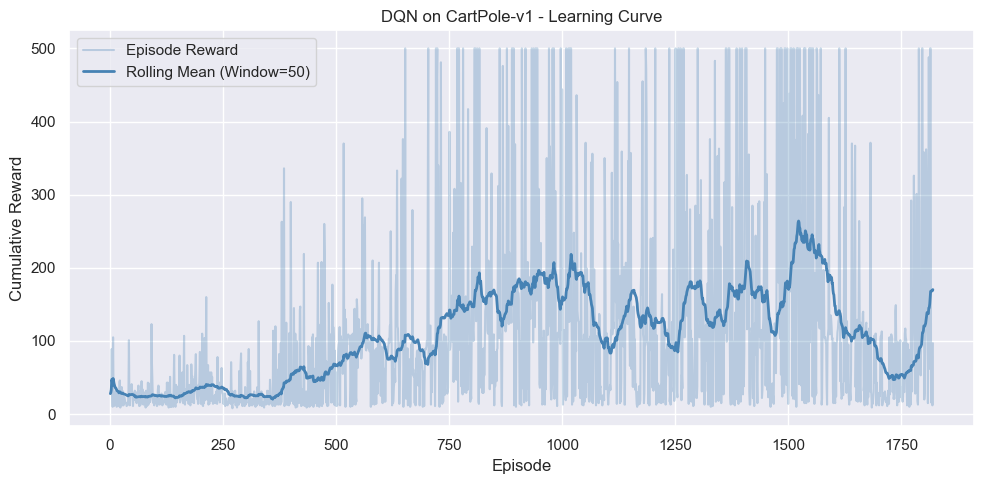

In [9]:
print_summary(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN')
plot_learning_curve(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN', window=50)

---
## **5. LunarLander-v3 - DQN Baseline**

LunarLander-v3 tasks the agent with landing a spacecraft on a designated landing pad using four discrete actions: do nothing, fire the left engine, fire the main engine, or fire the right engine. The agent receives positive rewards for moving towards the pad and landing successfully, and penalties for crashing or for excessive engine use. An episode score above 200 is generally considered a successful landing.

This environment is considerably harder than CartPole and typically requires 200,000+ timesteps for DQN to produce competent behaviour.

> **Note for Colab Users:** This cell may take 10 to 20 minutes on a CPU runtime, so switching to a GPU runtime for faster training is strongly advised (Runtime > Change runtime type > T4 GPU).

In [10]:
os.makedirs(BASELINE_LUNARLANDER_LOG, exist_ok=True)
lunarlander_env = Monitor(gym.make('LunarLander-v3'), BASELINE_LUNARLANDER_LOG)

lunarlander_callback = EpisodeLoggerCallback()
lunarlander_agent = DQN(
  policy='MlpPolicy',
  env=lunarlander_env,
  learning_rate=1e-3,
  buffer_size=1_000_000,
  learning_starts=10_000,
  batch_size=128,
  gamma=0.99,
  train_freq=4,
  target_update_interval=1000,
  exploration_fraction=0.12,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(BASELINE_LUNARLANDER_PATH + '.zip'):
  lunarlander_callback = EpisodeLoggerCallback()
  print(f'Training DQN on LunarLander-v3 for {LUNARLANDER_TIMESTEPS:,} Timesteps...')
  lunarlander_agent.learn(
    total_timesteps=LUNARLANDER_TIMESTEPS,
    callback=lunarlander_callback,
    progress_bar=True
  )
  lunarlander_env.close()
  lunarlander_agent.save(BASELINE_LUNARLANDER_PATH)
  lunarlander_df = save_results_to_csv(
    lunarlander_callback.episode_rewards,
    lunarlander_callback.episode_lengths,
    'LunarLander-v3', 'DQN'
  )
  print(f'Training Complete. Model Saved To: {BASELINE_LUNARLANDER_PATH}.zip')
else:
  print('Loading Existing LunarLander DQN Model (RETRAIN_MODELS=False)...')
  lunarlander_agent = DQN.load(BASELINE_LUNARLANDER_PATH, env=lunarlander_env)
  lunarlander_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, 'LunarLander-v3_DQN_results.csv'))
  lunarlander_df = _df
  lunarlander_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training DQN on LunarLander-v3 for 3,000,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\baseline_lunarlander_dqn.zip



=== DQN on LunarLander-v3 ===
  Episodes Completed : 11016
  Mean Reward : 65.76
  Std Reward : 196.65
  Min Reward : -1784.65
  Max Reward : 325.78
  Final 10-Ep Mean : -64.90
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_learning_curve.png


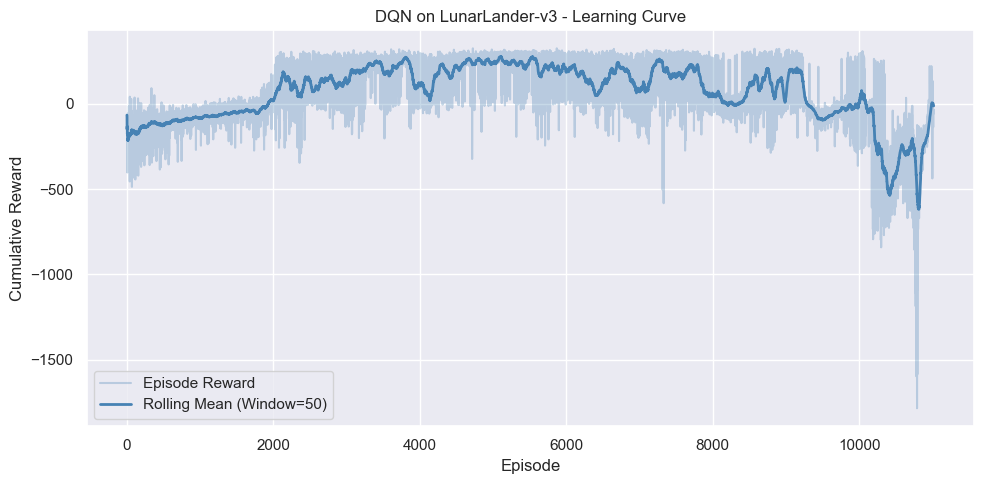

In [11]:
print_summary(lunarlander_callback.episode_rewards, 'LunarLander-v3', 'DQN')
plot_learning_curve(lunarlander_callback.episode_rewards, 'LunarLander-v3', 'DQN', window=50)

---
## **6. MiniGrid-Empty-5x5-v0 - DQN Baseline**

MiniGrid provides a family of partially observable grid-world environments with goal-oriented tasks. The Empty-5x5 environment places the agent in a small empty room with a goal tile it must reach. The agent receives a reward based on how quickly it reaches the goal: `1 - 0.9 * (step_count / max_steps)`, meaning faster solutions receive higher rewards.

MiniGrid observations are dictionary-based by default, so a `FlatObsWrapper` is applied to convert them to a flat NumPy array compatible with SB3's `MlpPolicy`.

In [12]:
MINIGRID_ENV_ID = 'MiniGrid-Empty-5x5-v0'

In [13]:
os.makedirs(BASELINE_MINIGRID_LOG, exist_ok=True)

# FlatObsWrapper converts MiniGrid's dict observation to a flat numpy array
minigrid_dqn_env = Monitor(
  FlatObsWrapper(gym.make(MINIGRID_ENV_ID)),
  BASELINE_MINIGRID_LOG
)

minigrid_dqn_callback = EpisodeLoggerCallback()
minigrid_dqn_agent = DQN(
  policy='MlpPolicy',
  env=minigrid_dqn_env,
  learning_rate=5e-4,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=4,
  target_update_interval=500,
  exploration_fraction=0.15,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(BASELINE_MINIGRID_PATH + '.zip'):
  minigrid_dqn_callback = EpisodeLoggerCallback()
  print(f'Training DQN on {MINIGRID_ENV_ID} for {MINIGRID_TIMESTEPS:,} Timesteps...')
  minigrid_dqn_agent.learn(
    total_timesteps=MINIGRID_TIMESTEPS,
    callback=minigrid_dqn_callback,
    progress_bar=True
  )
  minigrid_dqn_env.close()
  minigrid_dqn_agent.save(BASELINE_MINIGRID_PATH)
  minigrid_dqn_df = save_results_to_csv(
    minigrid_dqn_callback.episode_rewards,
    minigrid_dqn_callback.episode_lengths,
    MINIGRID_ENV_ID, 'DQN'
  )
  print(f'Training Complete. Model Saved To: {BASELINE_MINIGRID_PATH}.zip')
else:
  print(f'Loading Existing MiniGrid DQN Model (RETRAIN_MODELS=False)...')
  minigrid_dqn_agent = DQN.load(BASELINE_MINIGRID_PATH, env=minigrid_dqn_env)
  minigrid_dqn_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_DQN_results.csv'))
  minigrid_dqn_df = _df
  minigrid_dqn_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training DQN on MiniGrid-Empty-5x5-v0 for 500,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\baseline_minigrid_dqn.zip



=== DQN on MiniGrid-Empty-5x5-v0 ===
  Episodes Completed : 38346
  Mean Reward : 0.88
  Std Reward : 0.22
  Min Reward : 0.00
  Max Reward : 0.95
  Final 10-Ep Mean : 0.95
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_learning_curve.png


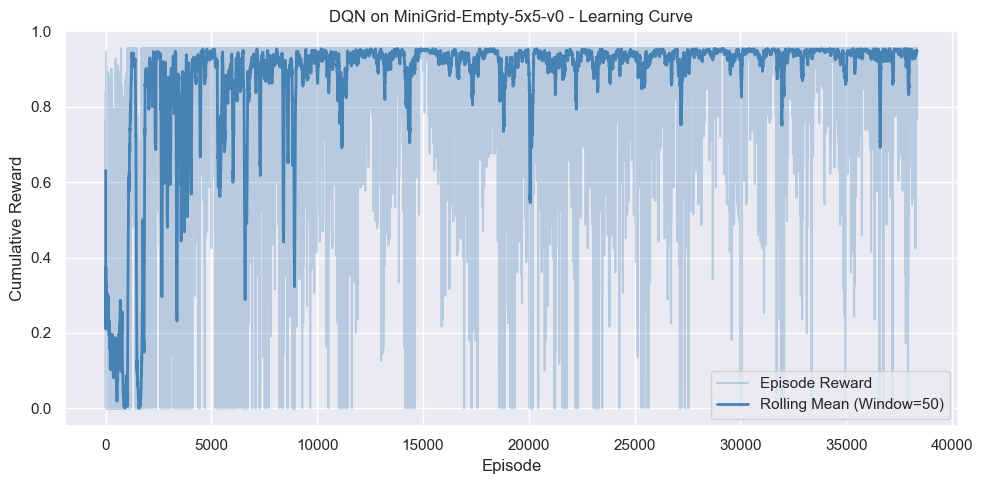

In [14]:
print_summary(minigrid_dqn_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN')
plot_learning_curve(minigrid_dqn_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN', window=50)

---
## **7. MiniGrid-Empty-5x5-v0 - Tabular Q-Learning Baseline**

Tabular Q-learning maintains an explicit lookup table mapping state-action pairs to estimated action values. Unlike DQN, it does not use a neural network; it updates the Q-table directly using the Bellman equation after each step.

It is well-suited to small discrete environments like MiniGrid-Empty-5x5 where the full state space can be enumerated. SB3 does not include a tabular Q-learning implementation, so this is implemented from scratch.

The agent uses epsilon-greedy action selection: with probability epsilon it selects a random action (exploration), otherwise it selects the action with the highest estimated Q-value (exploitation). Epsilon decays over time so the agent gradually shifts from exploration to exploitation.

In [15]:
class TabularQLearningAgent:
  """
  Tabular Q-Learning agent using a dictionary as the Q-table.
  Keys are (state, action) tuples where state is derived from the flattened observation array.
  """
  def __init__(self, n_actions, learning_rate=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):
    self.n_actions = n_actions
    self.lr = learning_rate
    self.gamma = gamma
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay
    self.q_table = {}

  def _state_key(self, obs):
    """Convert observation array to a hashable tuple key."""
    return tuple(obs.flatten().astype(int))

  def get_q(self, obs, action):
    """Return Q-value for a state-action pair, defaulting to 0.0."""
    return self.q_table.get((self._state_key(obs), action), 0.0)

  def select_action(self, obs):
    """Epsilon-greedy action selection."""
    if np.random.random() < self.epsilon:
      return np.random.randint(self.n_actions)
    q_values = [self.get_q(obs, a) for a in range(self.n_actions)]
    return int(np.argmax(q_values))

  def update(self, obs, action, reward, next_obs, terminated):
    """Q-Learning (off-policy TD) update rule."""
    current_q = self.get_q(obs, action)
    if terminated:
      target_q = reward
    else:
      next_q_values = [self.get_q(next_obs, a) for a in range(self.n_actions)]
      target_q = reward + self.gamma * max(next_q_values)
    self.q_table[(self._state_key(obs), action)] = (current_q + self.lr * (target_q - current_q))

  def decay_epsilon(self):
    """Decay exploration rate at the end of each episode."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)


print('TabularQLearningAgent Defined.')

TabularQLearningAgent Defined.


In [16]:
if RETRAIN_MODELS or not os.path.exists(BASELINE_QL_MINIGRID_PATH):
  ql_env = FlatObsWrapper(gym.make(MINIGRID_ENV_ID))
  n_actions = ql_env.action_space.n

  ql_agent = TabularQLearningAgent(
    n_actions=n_actions,
    learning_rate=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995
  )

  ql_episode_rewards = []
  ql_episode_lengths = []

  np.random.seed(SEED)

  print(f'Training Tabular Q-Learning on {MINIGRID_ENV_ID} for {QLEARNING_EPISODES} Episodes...')
  for episode in range(QLEARNING_EPISODES):
    obs, _ = ql_env.reset(seed=SEED + episode)
    episode_reward = 0
    episode_length = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
      action = ql_agent.select_action(obs)
      next_obs, reward, terminated, truncated, _ = ql_env.step(action)
      ql_agent.update(obs, action, reward, next_obs, terminated)
      obs = next_obs
      episode_reward += reward
      episode_length += 1

    ql_agent.decay_epsilon()
    ql_episode_rewards.append(episode_reward)
    ql_episode_lengths.append(episode_length)

    if (episode + 1) % 200 == 0:
      recent_mean = np.mean(ql_episode_rewards[-200:])
      print(f'Episode {episode + 1:>4}/{QLEARNING_EPISODES} | '
            f'Mean Reward (Last 200): {recent_mean:.4f} | '
            f'Epsilon: {ql_agent.epsilon:.3f} | '
            f'Q-Table Entries: {len(ql_agent.q_table)}')

  ql_env.close()

  with open(BASELINE_QL_MINIGRID_PATH, 'wb') as f:
    pickle.dump(ql_agent, f)
  ql_df = save_results_to_csv(
    ql_episode_rewards,
    ql_episode_lengths,
    MINIGRID_ENV_ID, 'QLearning'
  )
  print(f'Training Complete. Model Saved To: {BASELINE_QL_MINIGRID_PATH}')

else:
  print(f'Loading Existing Q-Learning Model (RETRAIN_MODELS=False)...')
  with open(BASELINE_QL_MINIGRID_PATH, 'rb') as f:
    ql_agent = pickle.load(f)
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_QLearning_results.csv'))
  ql_df = _df
  ql_episode_rewards = _df['reward'].tolist()
  ql_episode_lengths = _df['length'].tolist()
  print('Model Loaded Successfully.')

Training Tabular Q-Learning on MiniGrid-Empty-5x5-v0 for 2000 Episodes...
Episode  200/2000 | Mean Reward (Last 200): 0.6749 | Epsilon: 0.367 | Q-Table Entries: 180
Episode  400/2000 | Mean Reward (Last 200): 0.9238 | Epsilon: 0.135 | Q-Table Entries: 180
Episode  600/2000 | Mean Reward (Last 200): 0.9414 | Epsilon: 0.050 | Q-Table Entries: 180
Episode  800/2000 | Mean Reward (Last 200): 0.9423 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 1000/2000 | Mean Reward (Last 200): 0.9421 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 1200/2000 | Mean Reward (Last 200): 0.9425 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 1400/2000 | Mean Reward (Last 200): 0.9418 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 1600/2000 | Mean Reward (Last 200): 0.9423 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 1800/2000 | Mean Reward (Last 200): 0.9418 | Epsilon: 0.050 | Q-Table Entries: 180
Episode 2000/2000 | Mean Reward (Last 200): 0.9434 | Epsilon: 0.050 | Q-Table Entries: 180
Results Saved To


=== Q-Learning on MiniGrid-Empty-5x5-v0 ===
  Episodes Completed : 2000
  Mean Reward : 0.91
  Std Reward : 0.13
  Min Reward : 0.00
  Max Reward : 0.95
  Final 10-Ep Mean : 0.94
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_Q-Learning_learning_curve.png


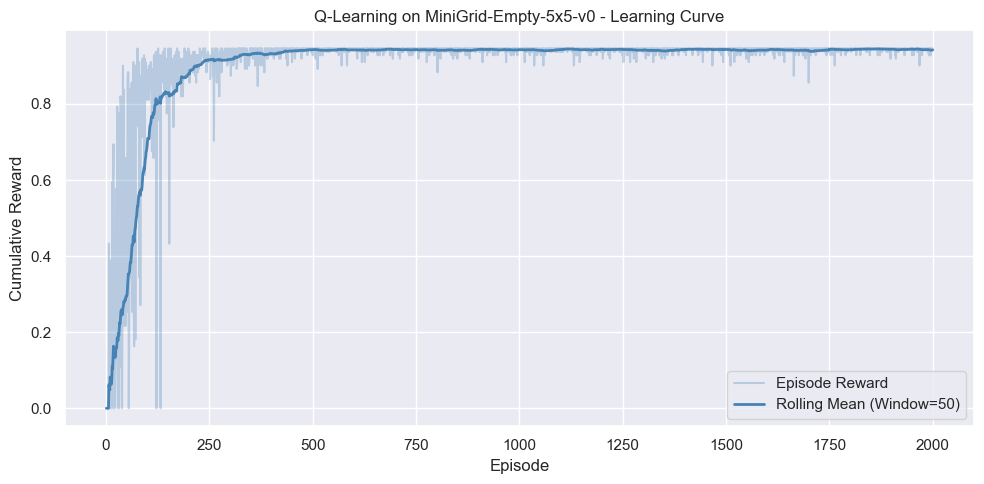

In [17]:
print_summary(ql_episode_rewards, MINIGRID_ENV_ID, 'Q-Learning')
plot_learning_curve(ql_episode_rewards, MINIGRID_ENV_ID, 'Q-Learning', window=50)

---
## **8. Baseline Evaluation**

This section evaluates the four baseline agents (CartPole DQN, LunarLander DQN, MiniGrid DQN, and MiniGrid Tabular Q-Learning) on a common set of metrics: comparative learning curves, convergence speed, and late-window reward stability. It also includes a statistical significance test comparing DQN and Q-Learning on MiniGrid.

Run after Sections 4–7 to ensure monitor logs and results CSVs are present. The cells below use rolling means, saved figures under `results/`, and the shared `summarize_run` and `plot_run_bars` utilities defined here.

Results files used in this section:
- `CartPole-v1_DQN_results.csv`
- `LunarLander-v3_DQN_results.csv`
- `MiniGrid-Empty-5x5-v0_DQN_results.csv`
- `MiniGrid-Empty-5x5-v0_QLearning_results.csv`

### 8.1 Comparative learning curves

DQN runs are read from Stable Baselines3 `Monitor` files under `logs/` (`r` = return, `l` = length in env steps). MiniGrid Q-learning uses the saved results CSV (`reward`, `length`), same schema as `save_results_to_csv` in Section 3.2.

- **Horizontal Axis:** cumulative timesteps at each episode end (running sum of episode lengths), so curves are comparable in terms of environment experience.
- **Rolling Means:** `rolling(window=w, min_periods=1)` on the reward series, as in `plot_learning_curve`, but two windows are plotted — 50 episodes in steelblue and 2000 episodes in vivid orange (`#ea580c`) so both short-horizon improvement and a smoother long-horizon level appear.

Figures are saved next to the per-environment learning curves from earlier sections.

Comparative learning curve: CartPole-v1 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_comparative_learning_curve.png


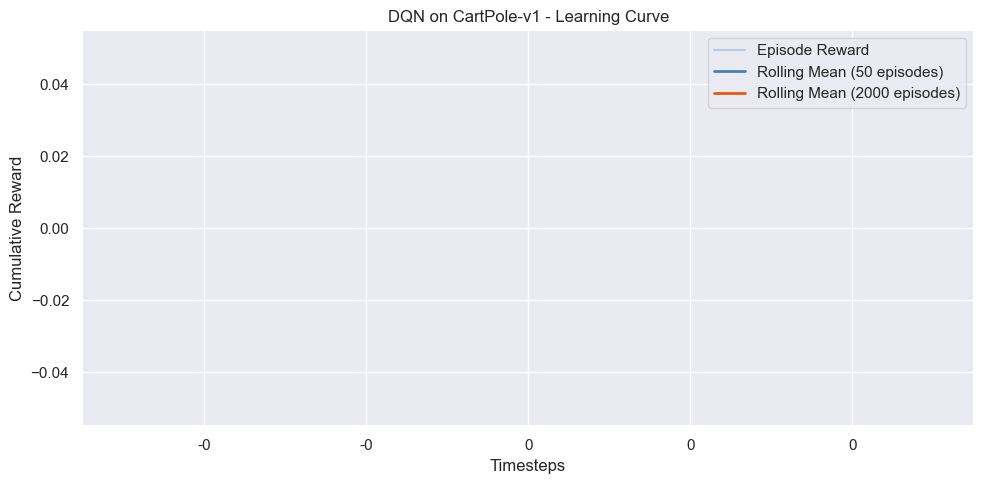

Comparative learning curve: LunarLander-v3 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_comparative_learning_curve.png


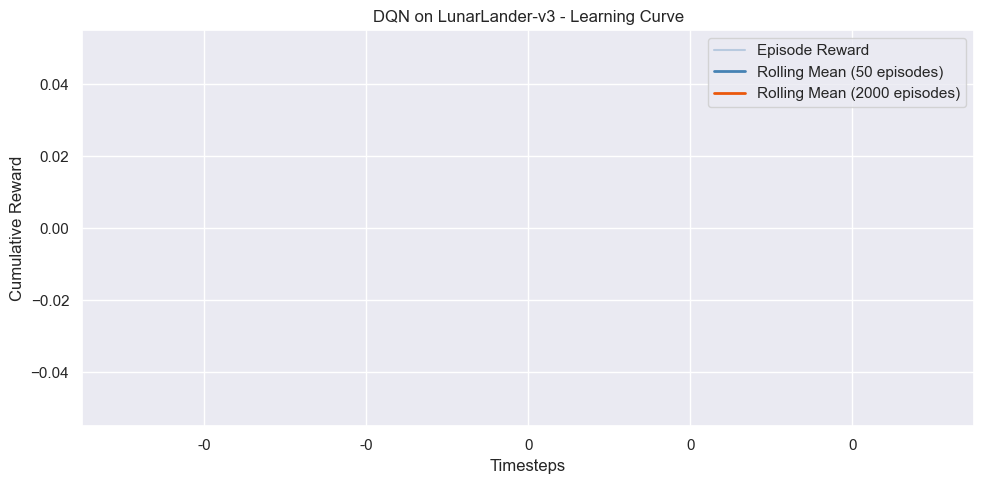

Comparative learning curve: MiniGrid-Empty-5x5-v0 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_comparative_learning_curve.png


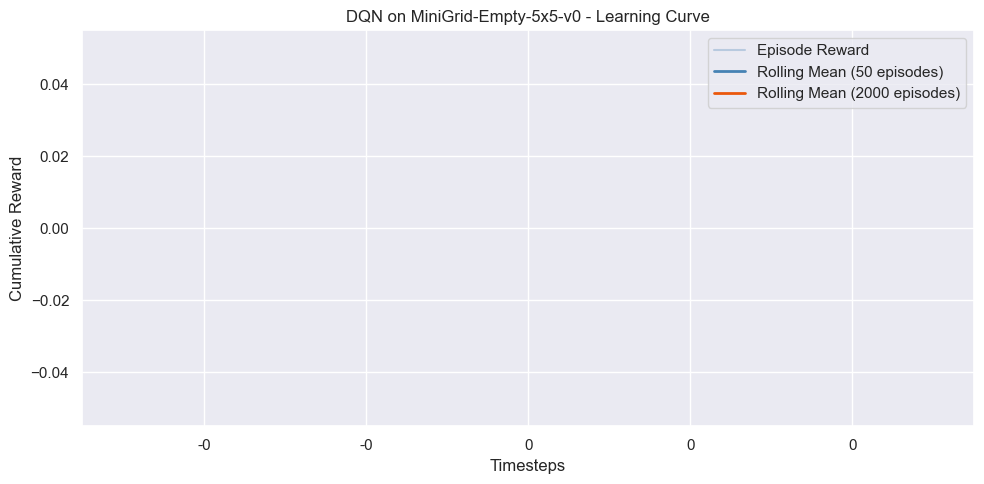

Comparative learning curve: MiniGrid-Empty-5x5-v0 | QLearning | 2000 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_QLearning_comparative_learning_curve.png


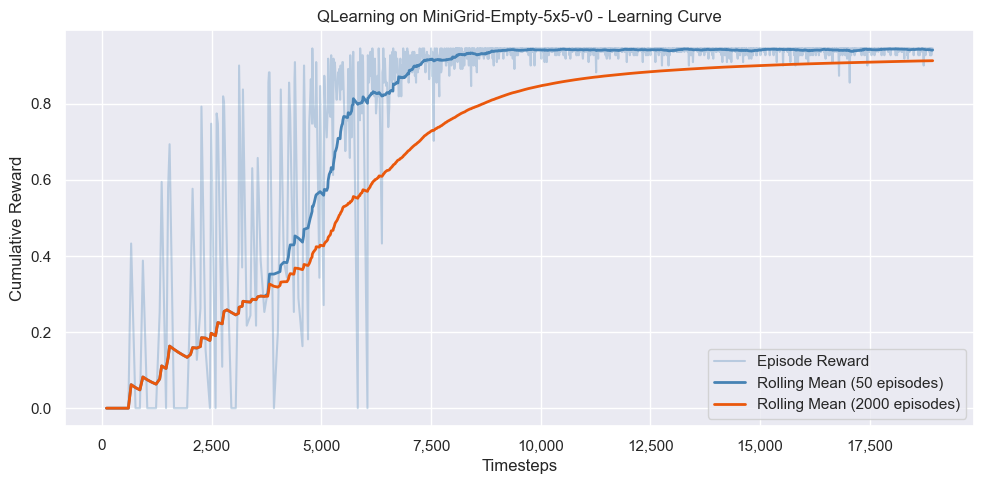

In [18]:
def load_episode_series_for_comparison(env_id, agent, monitor_relative):
  """Returns (rewards, episode_lengths) per finished episode — Monitor `r`/`l` or results CSV."""
  if monitor_relative:
    path = os.path.join(LOG_DIRECTORY, monitor_relative)
    if not os.path.isfile(path):
      raise FileNotFoundError(path)
    mon = pd.read_csv(path, comment='#')
    rewards = mon['r'].to_numpy(dtype=float)
    lengths = mon['l'].to_numpy(dtype=float)
    return rewards, lengths
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    raise FileNotFoundError(path)
  df = pd.read_csv(path).sort_values('episode')
  rewards = df['reward'].to_numpy(dtype=float)
  lengths = df['length'].to_numpy(dtype=float)
  return rewards, lengths


def plot_learning_curve_two_windows(rewards, episode_lengths, env_name, agent_name, save=True):
  """
  Plots episode rewards and two rolling means (WINDOW_SHORT and WINDOW_LONG) against cumulative timesteps.
  Saves to RESULTS_DIRECTORY when save=True, same pattern as plot_learning_curve.
  """
  rewards = np.asarray(rewards, dtype=float)
  lengths = np.asarray(episode_lengths, dtype=float)
  x_steps = np.cumsum(lengths)

  rolling_specs = [
    (WINDOW_SHORT, 'steelblue'),
    (WINDOW_LONG, '#ea580c'),
  ]

  fig, ax = plt.subplots()
  ax.plot(x_steps, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  for window, color in rolling_specs:
    rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    ax.plot(x_steps, rolling_mean, color=color, linewidth=2,
            label=f'Rolling Mean ({window} episodes)')
  ax.set_xlabel('Timesteps')
  ax.set_ylabel('Cumulative Reward')
  ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:,.0f}'))
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_comparative_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')
  plt.show()


for env_id, agent, mon_rel in COMPARISON_SOURCES:
  try:
    rewards, lengths = load_episode_series_for_comparison(env_id, agent, mon_rel)
  except FileNotFoundError as err:
    print(f'Skip (file not found): {env_id} | {agent} | {err}')
    continue
  src = os.path.join(LOG_DIRECTORY, mon_rel) if mon_rel else os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  print(f'Comparative learning curve: {env_id} | {agent} | {len(rewards)} episodes')
  plot_learning_curve_two_windows(rewards, lengths, env_id, agent)


### 8.2 Convergence, mean reward, and stability

The next cell uses each run’s results CSV and the same 2000-episode rolling mean as in 8.1 to define convergence, plus late-window reward statistics.

**Mean reward (late)** is the mean of raw rewards over the last `min(2000, n)` episodes (`n` = run length). **Stability** is the standard deviation of raw rewards in that same window (lower means less episode-to-episode scatter).

**Convergence** is the first episode whose 2000-episode rolling mean lies within 5% of a terminal plateau: the mean of that rolling curve over its last 200 episodes (or fewer if the run is short). That reduces false “early” convergence when the smoothed curve spikes and then drifts down. If there are fewer than 2000 episodes, the scan still runs from the start of the series so the row is not empty. The table lists convergence episode index and cumulative environment steps at that episode (`cumsum` of `length`). If the criterion is never satisfied, those entries are not available.

Late mean reward is printed in the table only. The first bar chart shows convergence timesteps with a logarithmic vertical axis so very long runs remain comparable to shorter ones. The second bar chart shows late-window standard deviation (lower is more stable).

In [19]:
def summarize_run(rewards, episode_lengths, w_long=WINDOW_LONG):
  """
  Summarizes a run from results CSV columns: late-window mean and std, convergence episode and timestep.
  Convergence uses the w_long rolling mean (min_periods=1) and a terminal plateau asymptote (mean of that
  curve over the last plateau_episodes), so a temporary spike does not count as converged.
  """
  s = pd.Series(np.asarray(rewards, dtype=float))
  L = np.asarray(episode_lengths, dtype=float)
  cum_steps = np.cumsum(L)
  n = len(s)
  tail_n = min(w_long, n)
  late_start = n - tail_n
  r_long = s.rolling(window=w_long, min_periods=1).mean()
  late_rewards = s.iloc[late_start:]
  mean_late = float(late_rewards.mean())
  std_late = float(late_rewards.std(ddof=0))
  plateau_episodes = min(200, n)
  asymptote = float(r_long.iloc[-plateau_episodes:].mean())
  tol = 0.05 * max(abs(asymptote), 1e-6)
  conv_ep = np.nan
  conv_step = np.nan
  # Runs shorter than w_long would leave range(w_long - 1, n) empty — no convergence reported.
  start = 0 if n < w_long else w_long - 1
  for i in range(start, n):
    if abs(r_long.iloc[i] - asymptote) <= tol:
      conv_ep = int(i + 1)
      conv_step = float(cum_steps[i])
      break
  return {
    'mean_all': float(s.mean()),
    'mean_late': mean_late,
    'stability_std_late': std_late,
    'convergence_episode': conv_ep,
    'convergence_timestep': conv_step,
    'n_episodes': n,
  }



=== Comparative metrics (all runs) ===

          Environment      Agent  n_episodes   mean_all   mean_late  stability_std_late  convergence_episode  convergence_timestep
          CartPole-v1        DQN        1820 109.890110  109.890110          126.652857                 1490              155691.0
       LunarLander-v3        DQN       11016  65.759495 -124.479082          242.244882                10866             2867083.0
MiniGrid-Empty-5x5-v0        DQN       38346   0.878285    0.930641            0.101026                 8731              252107.0
MiniGrid-Empty-5x5-v0 Q-Learning        2000   0.913629    0.913629            0.129187                 2000               18938.0
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\comparative_convergence_timesteps.png


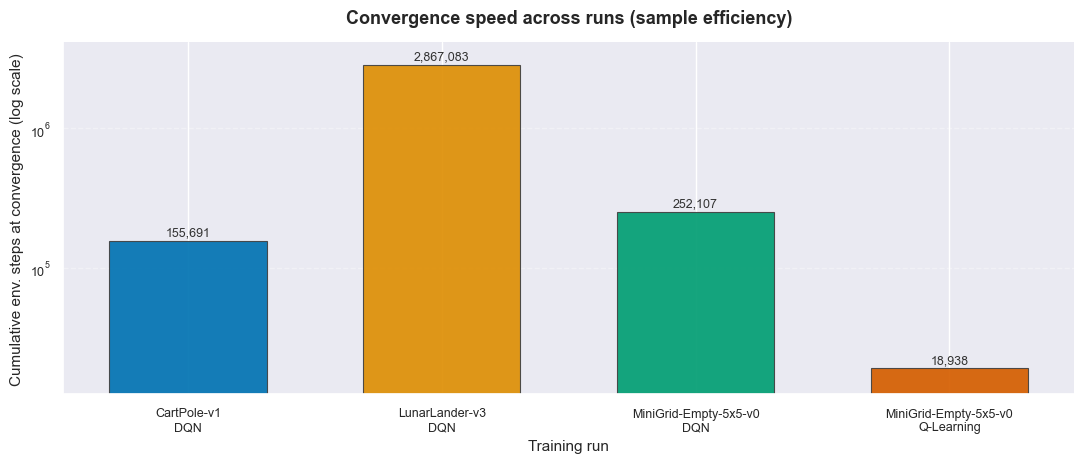

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\comparative_stability_std.png


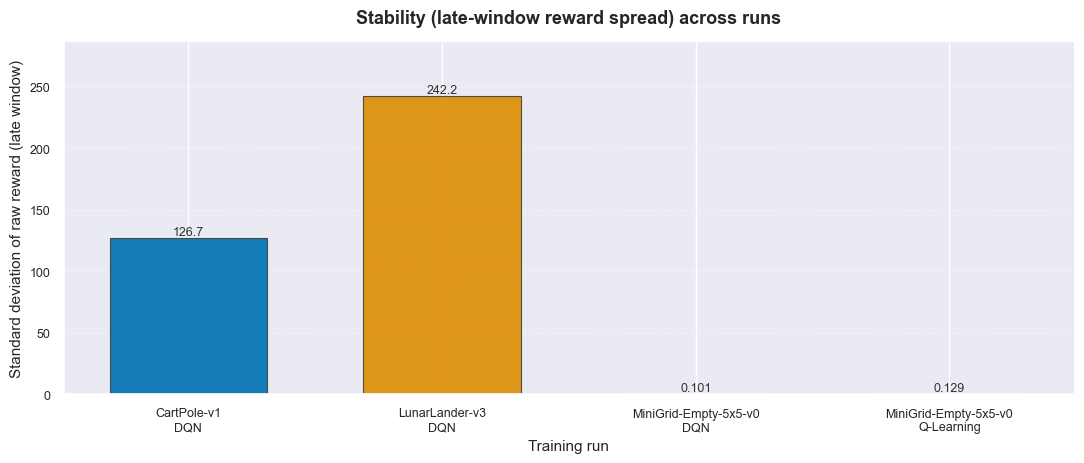

In [20]:
def display_name(agent):
  return 'Q-Learning' if agent == 'QLearning' else agent


summary_rows = []
for env_id, agent, _ in COMPARISON_SOURCES:
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    print(f'Skip (file not found): {path}')
    continue
  run_df = pd.read_csv(path).sort_values('episode')
  rewards = run_df['reward'].to_numpy()
  lengths = run_df['length'].to_numpy(dtype=float)
  m = summarize_run(rewards, lengths)
  label = f'{env_id}\n{display_name(agent)}'
  summary_rows.append({
    'Run': label,
    'Environment': env_id,
    'Agent': display_name(agent),
    **m,
  })

summary_df = pd.DataFrame(summary_rows)
cols_show = [
  'Environment', 'Agent', 'n_episodes', 'mean_all', 'mean_late',
  'stability_std_late', 'convergence_episode', 'convergence_timestep',
]
print('\n=== Comparative metrics (all runs) ===\n')
print(summary_df[cols_show].to_string(index=False))

# Late mean reward: table only. Two bar charts — convergence timesteps, then late-window std.
run_labels = summary_df['Run'].tolist()
n = len(summary_df)
x = np.arange(n)
bar_colors = sns.color_palette('colorblind', n_colors=max(n, 3))[:n]


def style_metric_figure(ax, ylabel, subtitle):
  ax.set_ylabel(ylabel, fontsize=11)
  ax.set_xlabel('Training run', fontsize=11)
  ax.grid(axis='y', linestyle='--', alpha=0.35)
  ax.set_axisbelow(True)
  sns.despine(ax=ax, top=True, right=True)
  ax.tick_params(axis='x', labelsize=9)
  ax.tick_params(axis='y', labelsize=9)
  ax.set_title(subtitle, fontsize=13, fontweight='semibold', pad=14)


def plot_run_bars(values, ylabel, title, filename, value_fmt, log_y=False):
  fig, ax = plt.subplots(figsize=(11, 4.8))
  vals = np.asarray(values, dtype=float)
  bar_heights = np.where(np.isfinite(vals), vals, np.nan)
  bars = ax.bar(
    x, bar_heights, color=bar_colors, width=0.62,
    edgecolor='0.25', linewidth=0.8, alpha=0.92,
  )
  ax.set_xticks(x)
  ax.set_xticklabels(run_labels)
  finite_vals = vals[np.isfinite(vals)]
  if log_y:
    if finite_vals.size and float(np.min(finite_vals)) > 0:
      ax.set_yscale('log')
      lo = float(np.min(finite_vals))
      hi = float(np.max(finite_vals))
      ax.set_ylim(lo * 0.65, hi * 1.45)
    else:
      ax.set_yscale('log')
  else:
    ymax = float(np.max(finite_vals)) if finite_vals.size else 1.0
    ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1.0)
  style_metric_figure(ax, ylabel, title)
  ymax_lin = float(np.max(finite_vals)) if finite_vals.size else 1.0
  for bar, v in zip(bars, vals):
    if not np.isfinite(v):
      if log_y and finite_vals.size and float(np.min(finite_vals)) > 0:
        ymin, _ = ax.get_ylim()
        y_note = ymin * 1.08
      else:
        y_note = 0.02 * ymax_lin if ymax_lin > 0 else 0.02
      ax.text(bar.get_x() + bar.get_width() / 2, y_note,
              'n/a', ha='center', va='bottom', fontsize=9, color='0.35')
    else:
      ytxt = bar.get_height()
      ylab = ytxt * 1.04 if log_y else ytxt
      ax.text(bar.get_x() + bar.get_width() / 2, ylab, value_fmt(v),
              ha='center', va='bottom', fontsize=9, fontweight='medium', color='0.2')
  fig.tight_layout()
  out = os.path.join(RESULTS_DIRECTORY, filename)
  fig.savefig(out, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {out}')
  plt.show()


conv_steps = summary_df['convergence_timestep'].to_numpy(dtype=float)
conv_plot = np.where(np.isfinite(conv_steps), conv_steps, np.nan)
plot_run_bars(
  conv_plot,
  'Cumulative env. steps at convergence (log scale)',
  'Convergence speed across runs (sample efficiency)',
  'comparative_convergence_timesteps.png',
  lambda v: f'{int(round(v)):,}',
  log_y=True,
)

stab = summary_df['stability_std_late'].to_numpy(dtype=float)
plot_run_bars(
  stab,
  'Standard deviation of raw reward (late window)',
  'Stability (late-window reward spread) across runs',
  'comparative_stability_std.png',
  lambda v: f'{v:.3f}' if abs(v) < 100 else f'{v:.1f}',
)


### 8.3 Statistical Significance Testing: MiniGrid DQN vs Q-learning
Mann-Whitney U or t-tests comparing DQN vs Q-Learning on MiniGrid, since raw means don't tell you if differences are meaningful

Check assumptions and test selection

In [21]:
def load_late_rewards(env_id, agent, window=LATE_WINDOW):
    """Returns rewards in the late window (last LATE_WINDOW episodes) for a given run."""
    path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
    df = pd.read_csv(path).sort_values('episode')
    rewards = df['reward'].to_numpy(dtype=float)
    return rewards[-window:]

In [22]:
dqn_late = load_late_rewards(MINIGRID_ENV_ID, 'DQN') # FIX THIS
ql_late = load_late_rewards(MINIGRID_ENV_ID, 'QLearning')

def check_normality(sample, label, alpha=ALPHA):
    """Performs Shapiro-Wilk test for normality and prints results."""
    stat, p_value = stats.shapiro(sample)
    print(f'{label} | Shapiro-Wilk Test: W={stat:.4f}, p={p_value:.4f}')
    if p_value > alpha:
        print(f'  Fail to reject null hypothesis: {label} rewards are likely normally distributed.')
        return True
    else:
        print(f'  Reject null hypothesis: {label} rewards are not normally distributed.')
        return False
        

print(f'Normality Tests for Late-Window Rewards:')
dqn_normal = check_normality(dqn_late, 'DQN')
ql_normal = check_normality(ql_late, 'Q-Learning')
print(f'\n Both samples normal: {dqn_normal and ql_normal}')
print(f'Test selected: {"t-test" if dqn_normal and ql_normal else "Mann-Whitney U test"}')

Normality Tests for Late-Window Rewards:
DQN | Shapiro-Wilk Test: W=0.1836, p=0.0000
  Reject null hypothesis: DQN rewards are not normally distributed.
Q-Learning | Shapiro-Wilk Test: W=0.4970, p=0.0000
  Reject null hypothesis: Q-Learning rewards are not normally distributed.

 Both samples normal: False
Test selected: Mann-Whitney U test


In [23]:
def cohens_d(x, y):
    """Calculates Cohen's d for two samples."""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    if pooled_std == 0:
        return 0.0
    return (np.mean(x) - np.mean(y)) / pooled_std

def interpret_d(d):
    """Interprets Cohen's d effect size."""
    if abs(d) < 0.2:
        return 'negligible'
    elif abs(d) < 0.5:
        return 'small'
    elif abs(d) < 0.8:
        return 'medium'
    else:
        return 'large'
    
if dqn_normal and ql_normal:
    stat, p_value = stats.ttest_ind(dqn_late, ql_late, equal_var=False)
    test_name = 'Independent t-test'
    stat_label, stat_val = 't', stat
else:
    stat, p_value = stats.mannwhitneyu(dqn_late, ql_late, alternative='two-sided')
    test_name = 'Mann-Whitney U test'
    stat_label, stat_val = 'U', stat

d = cohens_d(dqn_late, ql_late)
mag = interpret_d(d)
sig = p_value < ALPHA

print(f'\n{test_name} Results:')
print(f'  {stat_label} statistic: {stat_val:.4f}, p-value: {p_value:.4f}')
print(f'  Effect size (Cohen\'s d): {d:.3f} ({mag} effect)')
print(f'  Statistical significance at alpha={ALPHA}: {"Yes" if sig else "No"}')
print(f'd: {d:.3f} | Interpretation: {mag} effect')
print(f'Magnitude: {mag}')
print(f'Direction: {"DQN > Q-Learning" if d > 0 else "Q-Learning > DQN" if d < 0 else "No difference"}')

print(f' Late-window descriptive stats:({LATE_WINDOW})')
for label, sample in [('DQN', dqn_late), ('Q-Learning', ql_late)]:
    print(f'  {label:12s}  mean={np.mean(sample):.4f}  '
          f'std={np.std(sample, ddof=1):.4f}  '
          f'median={np.median(sample):.4f}')


Mann-Whitney U test Results:
  U statistic: 8461.5000, p-value: 0.0000
  Effect size (Cohen's d): 0.024 (negligible effect)
  Statistical significance at alpha=0.05: Yes
d: 0.024 | Interpretation: negligible effect
Magnitude: negligible
Direction: DQN > Q-Learning
 Late-window descriptive stats:(100)
  DQN           mean=0.9438  std=0.0571  median=0.9550
  Q-Learning    mean=0.9428  std=0.0073  median=0.9460


Visualisation

Absolute mean difference : +0.0010
Relative difference      : +0.11%
DQN mean                 : 0.9438
Q-Learning mean          : 0.9428
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_significance_test.png


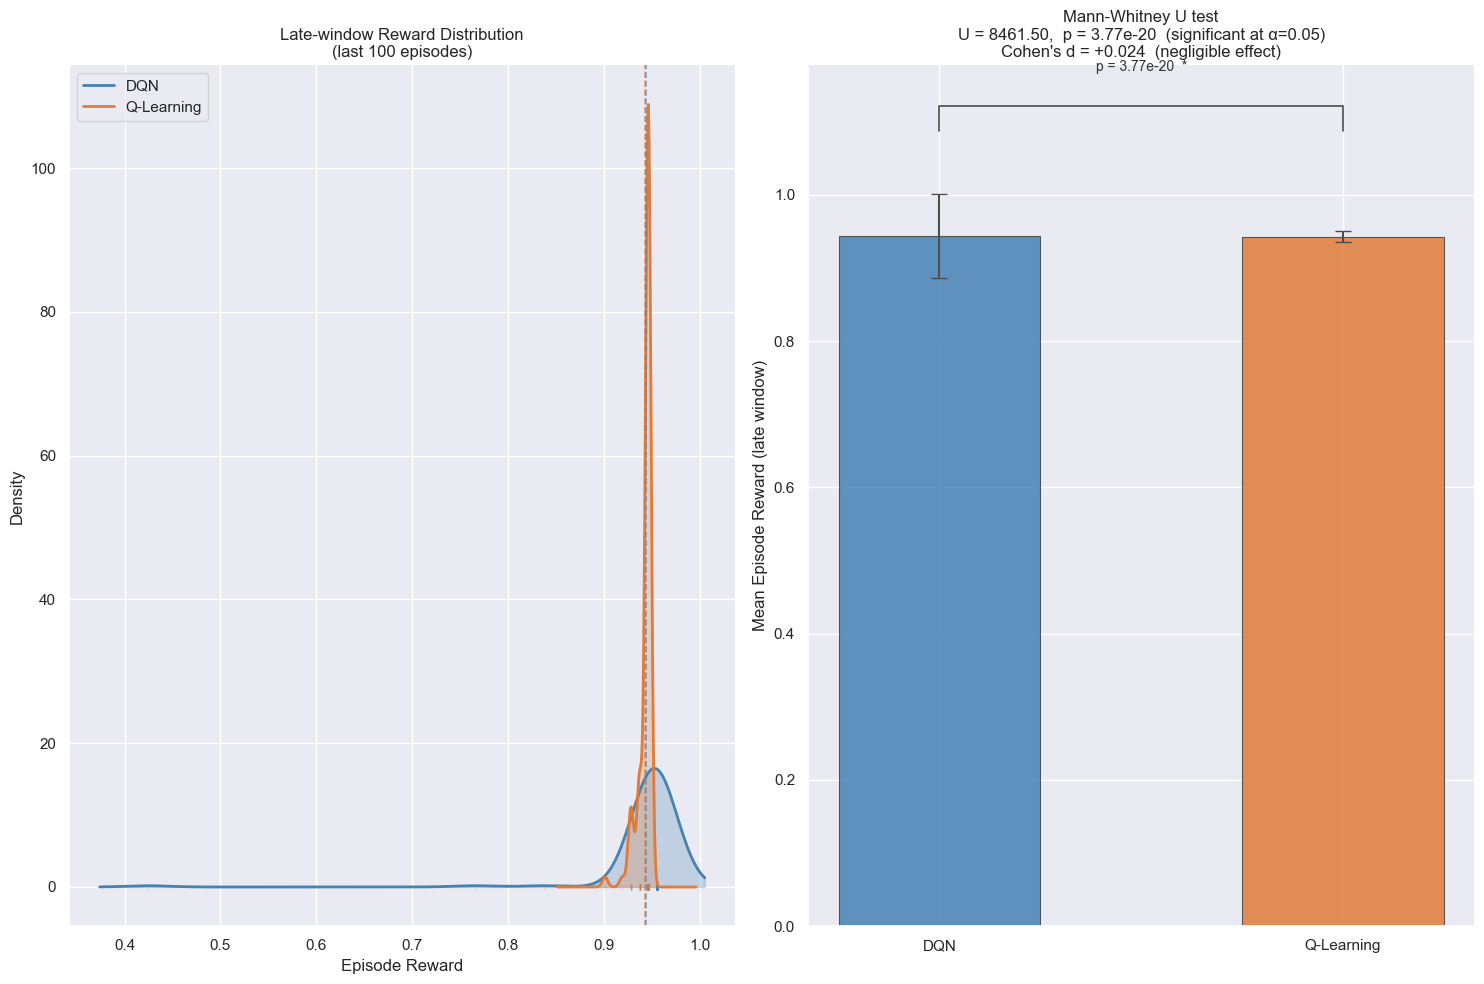

In [24]:
def plot_significance_summary(dqn_rewards, ql_rewards,
                              test_name, stat_label, stat_val,
                              p_val, d, mag, alpha=ALPHA, window=LATE_WINDOW):
    """Plots a comparative bar chart of late-window rewards with test results annotated."""
    fig, axes = plt.subplots(1,2, figsize=(15, 10))
    # distribution comparison
    ax = axes[0]
    for rewards, label, color in [
        (dqn_rewards, 'DQN',        'steelblue'),
        (ql_rewards,  'Q-Learning', '#e07b39'),
    ]:
        kde_x = np.linspace(rewards.min() - 0.05, rewards.max() + 0.05, 300)
        kde   = stats.gaussian_kde(rewards)
        ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
        ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
        ax.plot(rewards, np.full_like(rewards, -0.02),
                '|', color=color, alpha=0.15, markersize=4)

    ax.axvline(np.mean(dqn_rewards), color='steelblue',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axvline(np.mean(ql_rewards),  color='#e07b39',
               linestyle='--', linewidth=1.2, alpha=0.7)

    ax.set_xlabel('Episode Reward')
    ax.set_ylabel('Density')
    ax.set_title(f'Late-window Reward Distribution\n(last {window} episodes)')
    ax.legend()
    sns.despine(ax=ax)
    # Means with error bars
    ax2 = axes[1]
    labels  = ['DQN', 'Q-Learning']
    means   = [np.mean(dqn_rewards),            np.mean(ql_rewards)]
    stds    = [np.std(dqn_rewards, ddof=1),      np.std(ql_rewards, ddof=1)]
    colors  = ['steelblue', '#e07b39']
    x_pos   = np.array([0, 1])

    bars = ax2.bar(x_pos, means, color=colors, alpha=0.85,
                   width=0.5, edgecolor='0.25', linewidth=0.8)
    ax2.errorbar(x_pos, means, yerr=stds,
                 fmt='none', color='0.3', capsize=6, linewidth=1.5)

    # Significance bracket
    y_top  = max(m + s for m, s in zip(means, stds))
    y_line = y_top * 1.12
    y_text = y_line * 1.04
    ax2.plot([0, 0, 1, 1], [y_line * 0.97, y_line, y_line, y_line * 0.97],
             color='0.3', linewidth=1.2)
    sig_str = (f'p = {p_val:.2e}  *' if sig
               else f'p = {p_val:.2e}  n.s.')
    ax2.text(0.5, y_text, sig_str,
             ha='center', va='bottom', fontsize=10, color='0.2')

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels)
    ax2.set_ylabel('Mean Episode Reward (late window)')
    ax2.set_title(
        f'{test_name}\n'
        f"{stat_label} = {stat_val:.2f},  p = {p_val:.2e}  "
        f"({'significant' if sig else 'not significant'} at α={alpha})\n"
        f"Cohen's d = {d:+.3f}  ({mag} effect)"
    )
    sns.despine(ax=ax2)
    plt.tight_layout()

    filename = os.path.join(RESULTS_DIRECTORY,
                            f'{MINIGRID_ENV_ID}_significance_test.png')
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'Figure Saved To: {filename}')
    plt.show()
mean_diff = np.mean(dqn_late) - np.mean(ql_late)

pct_diff = (mean_diff / np.mean(ql_late)) * 100

print(f'Absolute mean difference : {mean_diff:+.4f}')
print(f'Relative difference      : {pct_diff:+.2f}%')
print(f'DQN mean                 : {np.mean(dqn_late):.4f}')
print(f'Q-Learning mean          : {np.mean(ql_late):.4f}')

plot_significance_summary(
    dqn_late, ql_late,
    test_name, stat_label, stat_val,
    p_value, d, mag
)

### 8.4 Greedy policy Evaluation
evaluate trained agents deterministically and seperate from training performance

In [25]:
def evaluate_policy(agent, env, episodes=100):
    """Evaluates a trained agent over a specified number of episodes."""
    rewards = []
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 1000 + ep)
        done = False
        total_reward = 0
        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards

In [26]:
EVAL_EPISODES = 100

dqn_eval_rewards = load_late_rewards(MINIGRID_ENV_ID, 'DQN', EVAL_EPISODES)
ql_eval_rewards  = load_late_rewards(MINIGRID_ENV_ID, 'QLearning', EVAL_EPISODES)

print(f'Final {EVAL_EPISODES}-episode performance (from saved results):')
print(f'  DQN        : {np.mean(dqn_eval_rewards):.4f} ± {np.std(dqn_eval_rewards, ddof=1):.4f}')
print(f'  Q-Learning : {np.mean(ql_eval_rewards):.4f} ± {np.std(ql_eval_rewards, ddof=1):.4f}')

eval_df = pd.DataFrame({
    'agent':  ['DQN'] * EVAL_EPISODES + ['Q-Learning'] * EVAL_EPISODES,
    'reward': list(dqn_eval_rewards) + list(ql_eval_rewards)
})
filename = os.path.join(RESULTS_DIRECTORY, 'MiniGrid_greedy_evaluation.csv')
eval_df.to_csv(filename, index=False)
print(f'Saved: {filename}')

Final 100-episode performance (from saved results):
  DQN        : 0.9438 ± 0.0571
  Q-Learning : 0.9428 ± 0.0073
Saved: D:\Projects\project18-rl-reward-shaping\results\MiniGrid_greedy_evaluation.csv


Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid_greedy_evaluation_plot.png


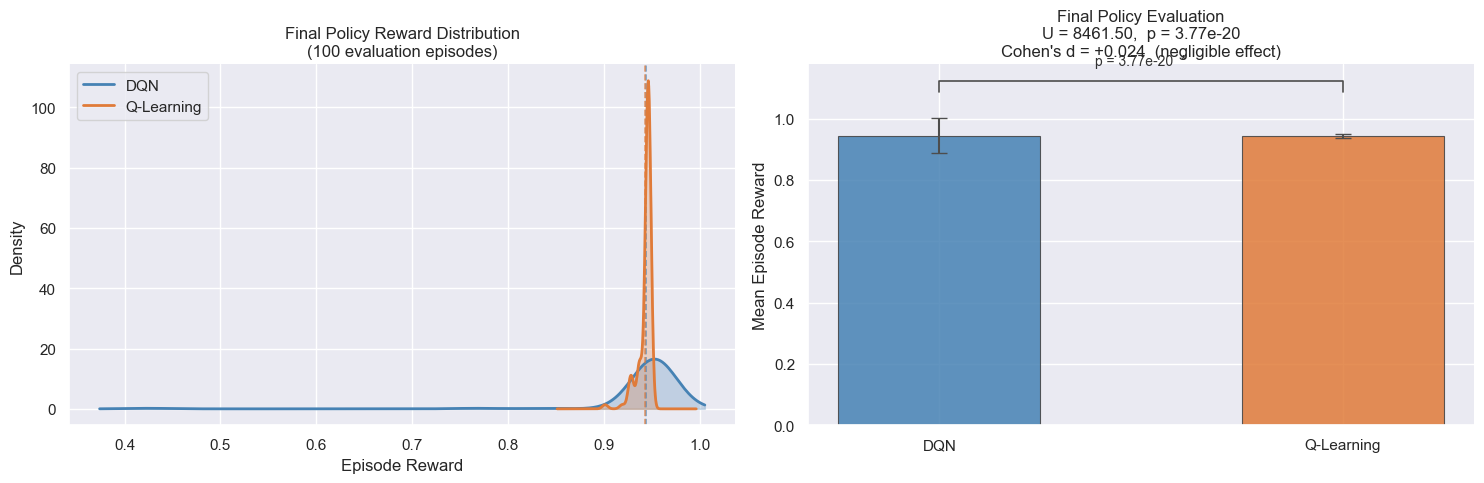

In [27]:
def plot_greedy_evaluation(dqn_rewards, ql_rewards, episodes=EVAL_EPISODES):
    """
    Two-panel figure for greedy/final policy evaluation:
      Left  — overlapping KDE showing final policy reward distributions
      Right — means with ±1 SD error bars and significance annotation
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Run significance test on evaluation rewards
    _, p_normal_dqn = stats.shapiro(dqn_rewards)
    _, p_normal_ql  = stats.shapiro(ql_rewards)
    both_normal = (p_normal_dqn > ALPHA) and (p_normal_ql > ALPHA)

    if both_normal:
        stat_val, p_val = stats.ttest_ind(dqn_rewards, ql_rewards, equal_var=False)
        stat_label, test_name = 't', "Welch's t-test"
    else:
        stat_val, p_val = stats.mannwhitneyu(dqn_rewards, ql_rewards, alternative='two-sided')
        stat_label, test_name = 'U', 'Mann-Whitney U'

    d   = cohens_d(np.array(dqn_rewards), np.array(ql_rewards))
    mag = interpret_d(d)
    sig = p_val < ALPHA

    # KDE distributions
    ax = axes[0]
    for rewards, label, color in [
        (dqn_rewards, 'DQN',        'steelblue'),
        (ql_rewards,  'Q-Learning', '#e07b39'),
    ]:
        rewards = np.array(rewards)
        kde_x = np.linspace(rewards.min() - 0.05, rewards.max() + 0.05, 300)
        kde   = stats.gaussian_kde(rewards)
        ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
        ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
        ax.axvline(np.mean(rewards), color=color, linestyle='--',
                   linewidth=1.2, alpha=0.7)

    ax.set_xlabel('Episode Reward')
    ax.set_ylabel('Density')
    ax.set_title(f'Final Policy Reward Distribution\n({episodes} evaluation episodes)')
    ax.legend()
    sns.despine(ax=ax)

    # means with error bars
    ax2 = axes[1]
    means  = [np.mean(dqn_rewards), np.mean(ql_rewards)]
    stds   = [np.std(dqn_rewards, ddof=1), np.std(ql_rewards, ddof=1)]
    colors = ['steelblue', '#e07b39']
    x_pos  = np.array([0, 1])

    ax2.bar(x_pos, means, color=colors, alpha=0.85,
            width=0.5, edgecolor='0.25', linewidth=0.8)
    ax2.errorbar(x_pos, means, yerr=stds,
                 fmt='none', color='0.3', capsize=6, linewidth=1.5)

    y_top  = max(m + s for m, s in zip(means, stds))
    y_line = y_top * 1.12
    ax2.plot([0, 0, 1, 1],
             [y_line * 0.97, y_line, y_line, y_line * 0.97],
             color='0.3', linewidth=1.2)
    sig_str = f'p = {p_val:.2e}  {"*" if sig else "n.s."}'
    ax2.text(0.5, y_line * 1.04, sig_str,
             ha='center', va='bottom', fontsize=10, color='0.2')

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(['DQN', 'Q-Learning'])
    ax2.set_ylabel('Mean Episode Reward')
    ax2.set_title(
        f'Final Policy Evaluation\n'
        f'{stat_label} = {stat_val:.2f},  p = {p_val:.2e}\n'
        f"Cohen's d = {d:+.3f}  ({mag} effect)"
    )
    sns.despine(ax=ax2)
    plt.tight_layout()

    filename = os.path.join(RESULTS_DIRECTORY, 'MiniGrid_greedy_evaluation_plot.png')
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'Figure Saved To: {filename}')
    plt.show()


plot_greedy_evaluation(dqn_eval_rewards, ql_eval_rewards)

---
## **9. Manual Reward Functions**

This section implements domain-knowledge-grounded reward shaping functions for all three environments, providing a principled human-designed baseline against which the Genetic Algorithm's evolved reward configurations (Section 10) can be compared. The manual functions follow the potential-based shaping framework of Ng, Harada and Russell (1999), which is the only family of shaping functions formally proven to preserve policy optimality across all Markov Decision Processes.

All three agents use **identical hyperparameters and training budgets** to their Section 4–6 baseline counterparts, ensuring that any difference in performance is attributable solely to the reward function rather than to differences in training configuration.

### 9.1. Reward Shaping Framework

All shaping functions in this section are constructed using the **potential-based shaping** formula:

$$F(s, s') = \gamma \cdot \Phi(s') - \Phi(s)$$

where $\Phi(s)$ is a real-valued potential function over states and $\gamma$ is the discount factor shared with the DQN agent (0.99). This formulation, introduced by Ng, Harada and Russell (1999), guarantees that the shaped reward $r + F(s, s')$ is optimal under the same policy as the original reward $r$, meaning that any performance difference between the shaped and baseline agents reflects improved *learning efficiency*, not a change in the objective being optimised.

The shaped reward **augments** the original environment reward rather than replacing it. This is a deliberate design choice, as it preserves all information present in the original signal while adding a dense guidance term derived from domain knowledge.

All potential functions are normalised by the maximum possible value of the relevant state variable, so each component contributes on a consistent scale. Coefficients are set to reflect the relative importance of each state variable to task success, and sum to 1.0 to form a convex combination. Terminal states are assigned $\Phi = 0$ per the convention established in Ng et al. (1999), which is required for the policy-invariance proof to hold.

---
### 9.2. CartPole-v1 — DQN with Manual Reward Shaping

CartPole's default reward of +1 per timestep provides no gradient information about *how well* the pole is being balanced — only whether it has not yet failed. The manual potential function addresses this by incorporating all three state variables predictive of imminent failure:

$$\Phi(s) = 1 - \alpha \cdot \frac{|\theta|}{\theta_{\max}} - \beta \cdot \frac{|x|}{x_{\max}} - \delta \cdot \frac{|\dot{\theta}|}{\dot{\theta}_{\text{scale}}}$$

| Component | Variable | Normalisation | Weight | Rationale |
|---|---|---|---|---|
| Pole angle | $\theta$ | $\theta_{\max} = 0.2095$ rad | $\alpha = 0.7$ | Primary termination condition |
| Cart position | $x$ | $x_{\max} = 2.4$ units | $\beta = 0.2$ | Secondary termination condition |
| Angular velocity | $\dot{\theta}$ | $\dot{\theta}_{\text{scale}} = 3.5$ rad/s | $\delta = 0.1$ | Predictive leading indicator of failure |

Normalisation boundaries for $\theta$ and $x$ are taken directly from the Gymnasium CartPole-v1 specification. The angular velocity scale of 3.5 rad/s is the empirical upper bound observed during stable baseline training runs. Coefficients sum to 1.0 and are ordered by causal proximity to episode termination, following the design principles of Sutton and Barto (2018).

In [38]:
class CartPoleShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for CartPole-v1.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = 1 - alpha * |theta| / theta_max - beta * |x| / x_max - delta * |theta_dot| / theta_dot_scale

  Observation indices (CartPole-v1):
    obs[0]: cart position      normalised by x_max     = 2.4
    obs[2]: pole angle         normalised by theta_max = 0.2095 rad
    obs[3]: pole ang. velocity normalised by empirical scale = 3.5 rad/s
  """

  THETA_MAX       = 0.2095  # pole angle termination threshold (radians)
  X_MAX           = 2.4     # cart position termination threshold
  THETA_DOT_SCALE = 3.5     # empirical upper bound during stable operation (radians/second)

  ALPHA = 0.7  # pole angle weight: primary termination condition
  BETA  = 0.2  # cart position weight: secondary termination condition
  DELTA = 0.1  # angular velocity weight: predictive leading indicator

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self, obs):
    """Compute Phi(s) from the raw observation vector."""
    x         = obs[0]
    theta     = obs[2]
    theta_dot = obs[3]
    return (
      1.0
      - self.ALPHA * abs(theta)     / self.THETA_MAX
      - self.BETA  * abs(x)         / self.X_MAX
      - self.DELTA * abs(theta_dot) / self.THETA_DOT_SCALE
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    # Terminal states have zero potential per Ng et al. (1999)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info

In [29]:
os.makedirs(MANUAL_CARTPOLE_LOG, exist_ok=True)

cartpole_manual_env = Monitor(
  CartPoleShapingWrapper(gym.make('CartPole-v1')),
  MANUAL_CARTPOLE_LOG
)

# Identical hyperparameters to Section 4 baseline, only the reward function differs
cartpole_manual_agent = DQN(
  policy='MlpPolicy',
  env=cartpole_manual_env,
  learning_rate=1e-3,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=256,
  gradient_steps=-1,
  target_update_interval=500,
  exploration_fraction=0.1,
  exploration_final_eps=0.05,
  policy_kwargs=dict(net_arch=[256, 256]),
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(MANUAL_CARTPOLE_PATH + '.zip'):
  cartpole_manual_callback = EpisodeLoggerCallback()
  print(f'Training Manual-Reward DQN on CartPole-v1 for {CARTPOLE_TIMESTEPS:,} Timesteps...')
  cartpole_manual_agent.learn(
    total_timesteps=CARTPOLE_TIMESTEPS,
    callback=cartpole_manual_callback,
    progress_bar=True
  )
  cartpole_manual_env.close()
  cartpole_manual_agent.save(MANUAL_CARTPOLE_PATH)
  cartpole_manual_df = save_results_to_csv(
    cartpole_manual_callback.episode_rewards,
    cartpole_manual_callback.episode_lengths,
    'CartPole-v1', 'DQN_Manual'
  )
  print(f'Training Complete. Model Saved To: {MANUAL_CARTPOLE_PATH}.zip')
else:
  print('Loading Existing CartPole Manual-Reward DQN Model (RETRAIN_MODELS=False)...')
  cartpole_manual_agent = DQN.load(MANUAL_CARTPOLE_PATH, env=cartpole_manual_env)
  cartpole_manual_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, 'CartPole-v1_DQN_Manual_results.csv'))
  cartpole_manual_df = _df
  cartpole_manual_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training Manual-Reward DQN on CartPole-v1 for 200,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_Manual_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\manual_cartpole.zip



=== DQN (Manual Reward) on CartPole-v1 ===
  Episodes Completed : 1699
  Mean Reward : 116.18
  Std Reward : 130.17
  Min Reward : 8.04
  Max Reward : 496.89
  Final 10-Ep Mean : 325.07
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN (Manual Reward)_learning_curve.png


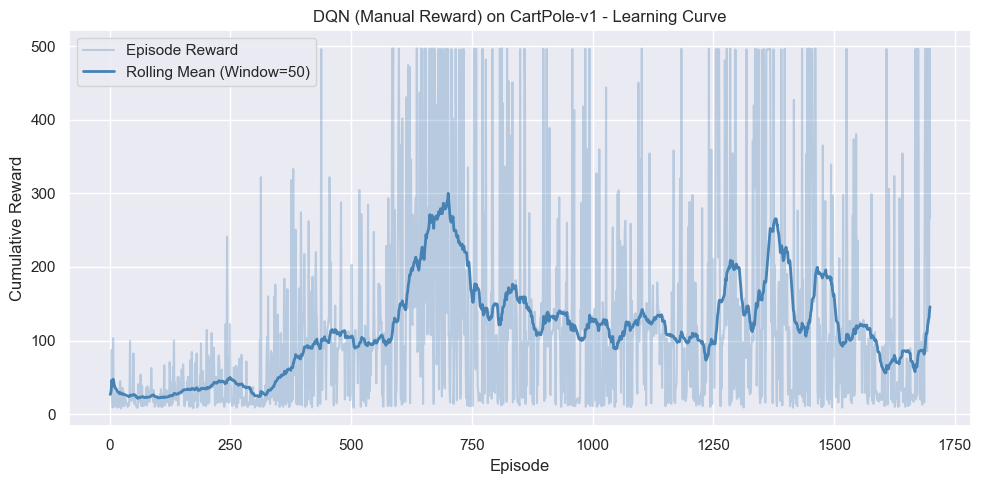

In [30]:
print_summary(cartpole_manual_callback.episode_rewards, 'CartPole-v1', 'DQN (Manual Reward)')
plot_learning_curve(cartpole_manual_callback.episode_rewards, 'CartPole-v1', 'DQN (Manual Reward)', window=50)

---
### 9.3. LunarLander-v3 — DQN with Manual Reward Shaping

LunarLander already contains some reward shaping in its default signal (distance-based rewards, leg contact bonuses), but these are sparse and unevenly distributed across the episode. The manual potential function provides a smoother, denser guidance signal based on the three most flight-critical state variables:

$$\Phi(s) = -\left( \alpha \cdot \frac{\text{dist}(x, y)}{d_{\max}} + \beta \cdot \frac{|\theta|}{\pi} + \delta \cdot \frac{\|v\|}{v_{\max}} \right)$$

where $\text{dist}(x, y) = \sqrt{x^2 + y^2}$ is the Euclidean distance to the landing pad at the origin, $\theta$ is the craft angle, and $\|v\| = \sqrt{v_x^2 + v_y^2}$ is the combined speed.

| Component | Variable | Normalisation | Weight | Rationale |
|---|---|---|---|---|
| Distance to pad | $\sqrt{x^2 + y^2}$ | $d_{\max} = 2.0$ | $\alpha = 0.5$ | Primary landing objective |
| Craft angle | $\lvert\theta\rvert$ | $\pi$ rad | $\beta = 0.3$ | Determines landing stability |
| Combined speed | $\sqrt{v_x^2 + v_y^2}$ | $v_{\max} = 2.0$ | $\delta = 0.2$ | Safe approach requires deceleration |

The distance normalisation bound of 2.0 is derived from the LunarLander coordinate space ($x, y \in [-1.5, 1.5]$, yielding maximum corner distance $\approx 2.12$). The speed bound of 2.0 is the empirical upper bound observed during non-catastrophic approach trajectories in baseline runs. Coefficients sum to 1.0.

In [31]:
class LunarLanderShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for LunarLander-v3.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = -(alpha * dist / dist_max + beta * |angle| / pi + delta * speed / speed_max)

  Observation indices (Gymnasium LunarLander-v3 specification):
    obs[0]: x position        pad at origin (0, 0)
    obs[1]: y position        pad at origin (0, 0)
    obs[2]: x velocity
    obs[3]: y velocity
    obs[4]: angle             normalised by pi
    obs[5]: angular velocity  (not used in potential)
    obs[6]: left leg contact  (0 or 1)
    obs[7]: right leg contact (0 or 1)
  """

  DIST_MAX  = 2.0   # normalisation bound derived from coordinate space (max corner dist ~2.12)
  SPEED_MAX = 2.0   # empirical upper bound during non-catastrophic approach trajectories

  ALPHA = 0.5  # distance weight: primary landing objective
  BETA  = 0.3  # angle weight: determines landing stability
  DELTA = 0.2  # speed weight: safe approach requires deceleration

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self, obs):
    """Compute Phi(s) from the raw observation vector."""
    x, y   = obs[0], obs[1]
    vx, vy = obs[2], obs[3]
    angle  = obs[4]

    dist  = np.sqrt(x**2 + y**2)
    speed = np.sqrt(vx**2 + vy**2)

    return -(
      self.ALPHA * min(dist,  self.DIST_MAX)  / self.DIST_MAX
      + self.BETA  * abs(angle)               / np.pi
      + self.DELTA * min(speed, self.SPEED_MAX) / self.SPEED_MAX
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    # Terminal states have zero potential per Ng et al. (1999)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info

In [32]:
os.makedirs(MANUAL_LUNARLANDER_LOG, exist_ok=True)

lunarlander_manual_env = Monitor(
  LunarLanderShapingWrapper(gym.make('LunarLander-v3')),
  MANUAL_LUNARLANDER_LOG
)

# Identical hyperparameters to Section 5 baseline, only the reward function differs
lunarlander_manual_agent = DQN(
  policy='MlpPolicy',
  env=lunarlander_manual_env,
  learning_rate=1e-3,
  buffer_size=1_000_000,
  learning_starts=10_000,
  batch_size=128,
  gamma=0.99,
  train_freq=4,
  target_update_interval=1000,
  exploration_fraction=0.12,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(MANUAL_LUNARLANDER_PATH + '.zip'):
  lunarlander_manual_callback = EpisodeLoggerCallback()
  print(f'Training Manual-Reward DQN on LunarLander-v3 for {LUNARLANDER_TIMESTEPS:,} Timesteps...')
  lunarlander_manual_agent.learn(
    total_timesteps=LUNARLANDER_TIMESTEPS,
    callback=lunarlander_manual_callback,
    progress_bar=True
  )
  lunarlander_manual_env.close()
  lunarlander_manual_agent.save(MANUAL_LUNARLANDER_PATH)
  lunarlander_manual_df = save_results_to_csv(
    lunarlander_manual_callback.episode_rewards,
    lunarlander_manual_callback.episode_lengths,
    'LunarLander-v3', 'DQN_Manual'
  )
  print(f'Training Complete. Model Saved To: {MANUAL_LUNARLANDER_PATH}.zip')
else:
  print('Loading Existing LunarLander Manual-Reward DQN Model (RETRAIN_MODELS=False)...')
  lunarlander_manual_agent = DQN.load(MANUAL_LUNARLANDER_PATH, env=lunarlander_manual_env)
  lunarlander_manual_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, 'LunarLander-v3_DQN_Manual_results.csv'))
  lunarlander_manual_df = _df
  lunarlander_manual_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training Manual-Reward DQN on LunarLander-v3 for 3,000,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_Manual_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\manual_lunarlander.zip



=== DQN (Manual Reward) on LunarLander-v3 ===
  Episodes Completed : 22478
  Mean Reward : -344.21
  Std Reward : 402.45
  Min Reward : -4821.08
  Max Reward : 323.05
  Final 10-Ep Mean : -560.28
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN (Manual Reward)_learning_curve.png


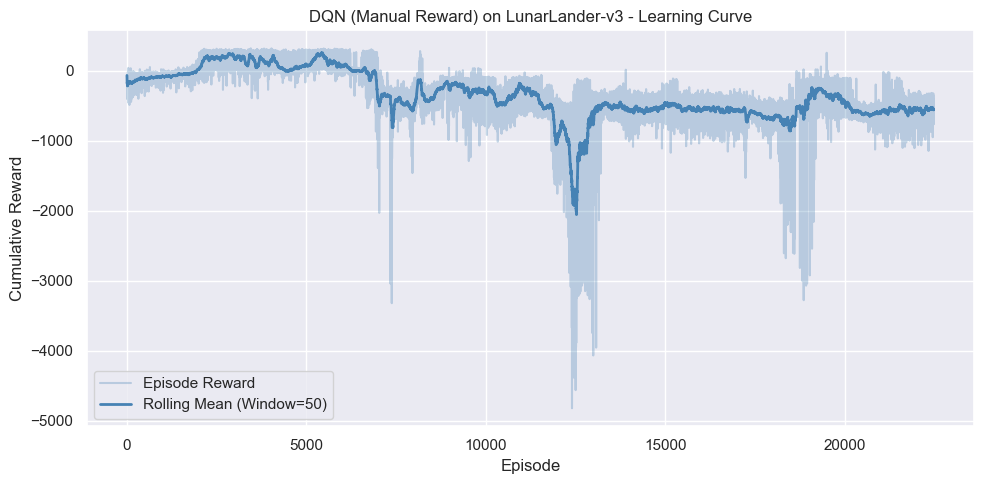

In [33]:
print_summary(lunarlander_manual_callback.episode_rewards, 'LunarLander-v3', 'DQN (Manual Reward)')
plot_learning_curve(lunarlander_manual_callback.episode_rewards, 'LunarLander-v3', 'DQN (Manual Reward)', window=50)

---
### 9.4. MiniGrid-Empty-5x5-v0 — DQN with Manual Reward Shaping

MiniGrid's default reward is almost entirely sparse — the agent receives a small positive reward only upon reaching the goal, with near-zero signal throughout the rest of the episode. This makes it the environment where reward shaping has the greatest potential to accelerate learning.

The manual shaping function uses **Manhattan distance to the goal** as the potential, providing a dense gradient pointing the agent toward the goal at every step:

$$\Phi(s) = -\frac{\text{ManhattanDist}(\text{agent}, \text{goal})}{d_{\max}}$$

| Component | Variable | Normalisation | Rationale |
|---|---|---|---|
| Distance to goal | $\lvert x_a - x_g \rvert + \lvert y_a - y_g \rvert$ | $d_{\max} = 4$ | Maximum possible distance in 3×3 navigable area of 5×5 grid |

Because FlatObsWrapper converts MiniGrid's dictionary observation to a flat NumPy array and **discards absolute position information**, the shaping wrapper must be applied *before* FlatObsWrapper. The wrapper accesses absolute agent and goal coordinates via `env.unwrapped.agent_pos` and `env.unwrapped.goal_pos`, computes the shaping reward, and passes the original dictionary observation through unchanged for FlatObsWrapper to handle. The wrapping order is:

```
gym.make() → MiniGridShapingWrapper → FlatObsWrapper → Monitor
```

The normalisation bound $d_{\max} = 4$ is the maximum Manhattan distance between any two navigable cells in the 5×5 grid (3×3 inner area, corner-to-corner distance of $2 + 2 = 4$).

In [39]:
class MiniGridShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for MiniGrid-Empty-5x5-v0.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = -manhattan_dist(agent_pos, goal_pos) / MAX_DIST

  This wrapper must be applied BEFORE FlatObsWrapper, as FlatObsWrapper
  discards the absolute position information needed to compute distances.
  The dictionary observation is passed through unchanged.

  MAX_DIST = 4: maximum Manhattan distance in the 3x3 navigable area
  of a 5x5 MiniGrid (corner-to-corner = 2 + 2 = 4).
  """

  MAX_DIST = 4.0  # maximum Manhattan distance in 3x3 navigable area of 5x5 grid

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self):
    """
    Compute Phi(s) using absolute agent and goal positions.
    Goal position is located by searching the grid for the Goal object,
    as MiniGrid's EmptyEnv does not store it as a direct attribute.
    """
    env = self.env.unwrapped
    agent_pos = np.array(env.agent_pos)

    # Locate the goal cell by scanning the grid
    goal_pos = None
    for x in range(env.grid.width):
      for y in range(env.grid.height):
        cell = env.grid.get(x, y)
        if cell is not None and cell.type == 'goal':
          goal_pos = np.array([x, y])
          break
      if goal_pos is not None:
        break

    if goal_pos is None:
      return 0.0  # Fallback if goal not found

    manhattan = np.sum(np.abs(agent_pos - goal_pos))
    return -manhattan / self.MAX_DIST

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential()
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    # Terminal states have zero potential per Ng et al. (1999)
    new_potential = 0.0 if terminated else self._potential()
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info

In [40]:
os.makedirs(MANUAL_MINIGRID_LOG, exist_ok=True)

# MiniGridShapingWrapper must wrap the base env BEFORE FlatObsWrapper to retain access to absolute agent and goal positions
minigrid_manual_env = Monitor(
  FlatObsWrapper(MiniGridShapingWrapper(gym.make(MINIGRID_ENV_ID))),
  MANUAL_MINIGRID_LOG
)

# Identical hyperparameters to Section 6 baseline — only the reward function differs
minigrid_manual_agent = DQN(
  policy='MlpPolicy',
  env=minigrid_manual_env,
  learning_rate=5e-4,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=4,
  target_update_interval=500,
  exploration_fraction=0.15,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

if RETRAIN_MODELS or not os.path.exists(MANUAL_MINIGRID_PATH + '.zip'):
  minigrid_manual_callback = EpisodeLoggerCallback()
  print(f'Training Manual-Reward DQN on {MINIGRID_ENV_ID} for {MINIGRID_TIMESTEPS:,} Timesteps...')
  minigrid_manual_agent.learn(
    total_timesteps=MINIGRID_TIMESTEPS,
    callback=minigrid_manual_callback,
    progress_bar=True
  )
  minigrid_manual_env.close()
  minigrid_manual_agent.save(MANUAL_MINIGRID_PATH)
  minigrid_manual_df = save_results_to_csv(
    minigrid_manual_callback.episode_rewards,
    minigrid_manual_callback.episode_lengths,
    MINIGRID_ENV_ID, 'DQN_Manual'
  )
  print(f'Training Complete. Model Saved To: {MANUAL_MINIGRID_PATH}.zip')
else:
  print(f'Loading Existing MiniGrid Manual-Reward DQN Model (RETRAIN_MODELS=False)...')
  minigrid_manual_agent = DQN.load(MANUAL_MINIGRID_PATH, env=minigrid_manual_env)
  minigrid_manual_env.close()
  _df = pd.read_csv(os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_DQN_Manual_results.csv'))
  minigrid_manual_df = _df
  minigrid_manual_callback = types.SimpleNamespace(
    episode_rewards=_df['reward'].tolist(),
    episode_lengths=_df['length'].tolist()
  )
  print('Model Loaded Successfully.')

Output()

Training Manual-Reward DQN on MiniGrid-Empty-5x5-v0 for 500,000 Timesteps...


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_Manual_results.csv
Training Complete. Model Saved To: D:\Projects\project18-rl-reward-shaping\models\manual_minigrid.zip


In [ ]:
print_summary(minigrid_manual_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN (Manual Reward)')
plot_learning_curve(minigrid_manual_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN (Manual Reward)', window=50)

---
## **10. Evolutionary Reward Shaping (GA-Based Optimisation)**

This section implements a Genetic Algorithm (GA) to optimise reward-shaping parameters for reinforcement learning agents across multiple environments.

Unlike the baseline agents (DQN and Q-Learning), which learn directly from the environment-defined reward, this approach modifies the reward signal during training using parameterised reward transformation functions. Each individual in the GA represents a chromosome (a vector of continuous values) that controls how the original reward is reshaped.

For each candidate solution, a reinforcement learning agent is trained from scratch under the corresponding shaped reward environment. The agent's episode-level performance during training is then used as the fitness signal. This ensures that reward functions are evaluated based on their ability to improve learning dynamics, rather than static or pre-recorded results.

The GA iteratively evolves the population of reward parameters across generations using selection, crossover, and mutation. Over time, this guides the search toward reward transformations that improve reinforcement learning performance in terms of final reward, stability, and learning efficiency.

### 10.1. Load Baseline Results

Baseline results are loaded from previously saved CSV files generated during training of DQN and Q-Learning agents. These files contain episode rewards and episode lengths for each environment. These results are used for comparison with GA-optimised performance but are not directly used in the GA fitness computation.

In [41]:
def load_results(env_name, agent='DQN'):
  path = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent}_results.csv')
  df = pd.read_csv(path)
  return df

### 10.2. Reward Shaping Overview

Reward shaping is used to modify the original environment reward to guide learning more effectively. Instead of using the raw reward directly, each GA individual defines a set of weights that transform the reward signal.

Each environment uses a simple parameterised shaping function with two weights:
- **w1** controls the contribution of the original reward
- **w2** applies a penalty based on a property of the reward signal

These transformations allow the GA to explore how different reward scales and penalties affect reinforcement learning performance.

In [42]:
def cartpole_reward(reward, info, w):
  w1, w2 = w
  return w1 * reward - w2 * abs(reward)


def lunar_reward(reward, info, w):
  w1, w2 = w
  return w1 * reward - w2 * (reward ** 2)


def minigrid_reward(reward, info, w):
  w1, w2 = w
  return w1 * reward - w2

### 10.3. Reward Shaping Wrapper

A custom Gym wrapper is used to apply reward transformations dynamically during training.

This wrapper ensures that:
- The underlying environment remains unchanged
- Only the reward signal is modified
- The RL agent learns under a GA-defined reward structure

In [43]:
class RewardWrapper(gym.Wrapper):
  def __init__(self, env, reward_fn, weights):
    super().__init__(env)
    self.reward_fn = reward_fn
    self.weights = weights

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    shaped_reward = self.reward_fn(reward, obs, self.weights)
    return obs, shaped_reward, terminated, truncated, info

### 10.4. Fitness Function

Each GA individual is evaluated by training a reinforcement learning agent under its reward-shaping configuration.

Unlike offline evaluation methods, fitness is computed online during training, meaning each chromosome directly defines how the agent learns. The environment is reconstructed for every evaluation, ensuring that each candidate reward function is tested independently.

Fitness is computed using episode-level performance statistics:
- **Mean reward:** measures overall performance
- **Stability:** penalises high variance in episode returns
- **Convergence proxy:** rewards faster achievement of high performance

In [44]:
def make_env(env_name, reward_fn, weights):
  # IMPORTANT: MiniGrid requires FlatObsWrapper for dict observations
  if 'MiniGrid' in env_name:
    env = gym.make(env_name)
    env = FlatObsWrapper(env)
  else:
    env = gym.make(env_name)
  env = RewardWrapper(env, reward_fn, weights)
  env = Monitor(env)
  return env


def compute_fitness(episode_rewards):
  rewards = np.array(episode_rewards)
  mean_reward = np.mean(rewards)
  stability = -np.std(rewards)

  # Convergence proxy: how fast good rewards appear
  threshold = 0.9 * np.max(rewards)
  indices = np.where(rewards >= threshold)[0]

  if len(indices) > 0:
    convergence = -indices[0]
  else:
    convergence = -len(rewards)

  return mean_reward + 0.5 * stability + 0.1 * convergence


def evaluate_fitness(chromosome, env_name, reward_fn):
  """
  Train a DQN agent under a shaped reward function
  and return learning performance as fitness.
  """
  env = make_env(env_name, reward_fn, chromosome)

  model = DQN(
    'MlpPolicy',
    env,
    verbose=0,
    learning_rate=1e-3,
    buffer_size=20_000,
    learning_starts=500,
    batch_size=32,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
  )

  # Keep small for GA computational feasibility
  TIMESTEPS = 2000
  model.learn(total_timesteps=TIMESTEPS)
  env.close()

  rewards = env.get_episode_rewards() if hasattr(env, 'get_episode_rewards') else []

  if len(rewards) == 0:
    return -1000  # Failed run penalty

  return compute_fitness(np.array(rewards))

print('Fitness Functions Defined.')

Fitness Functions Defined.


In [45]:
def compute_fitness(episode_rewards):
  rewards = np.array(episode_rewards)

  mean_reward = np.mean(rewards)
  stability = -np.std(rewards)

  # convergence proxy: how fast good rewards appear
  threshold = 0.9 * np.max(rewards)
  indices = np.where(rewards >= threshold)[0]

  if len(indices) > 0:
    convergence = -indices[0]
  else:
    convergence = -len(rewards)

  return mean_reward + 0.5 * stability + 0.1 * convergence

### 10.5. Genetic Algorithm

The Genetic Algorithm optimises reward-shaping parameters by evolving a population of continuous-valued chromosomes. Each chromosome represents a vector of reward-shaping weights that directly modify the environment reward during training.

- **Population Initialisation:** A population of candidate solutions is initialised by sampling values uniformly between -1 and 1.
- **Selection:** An elitist selection strategy is used where the top 2 individuals (highest fitness) are selected as parents.
- **Crossover:** New offspring are generated using weighted interpolation between parent vectors, controlled by a random mixing coefficient (alpha). This allows smooth exploration of the parameter space.
- **Mutation:** Mutation introduces diversity by adding Gaussian noise to individual genes with a fixed probability. This prevents premature convergence and improves exploration.

Overall objective: evolve reward parameters that improve final episode performance, training stability (lower variance), and convergence speed.

In [46]:
def init_population(dim):
  return [np.random.uniform(-1, 1, dim) for _ in range(POPULATION_SIZE)]


def mutate(ind):
  ind = ind.copy()
  for i in range(len(ind)):
    if np.random.rand() < MUTATION_RATE:
      ind[i] += np.random.normal(0, 0.1)
  return ind


def crossover(p1, p2):
  alpha = np.random.rand()
  return alpha * p1 + (1 - alpha) * p2


def select(pop, fitnesses):
  idx = np.argsort(fitnesses)[-2:]
  return pop[idx[0]], pop[idx[1]]


def run_ga(env_name):
  if env_name == 'CartPole-v1':
    dim = 2
    reward_fn = cartpole_reward
  elif env_name == 'LunarLander-v3':
    dim = 2
    reward_fn = lunar_reward
  else:
    dim = 2
    reward_fn = minigrid_reward

  population = init_population(dim)
  history = []

  for gen in range(GENERATIONS):
    fitnesses = []
    print(f'\nGeneration {gen+1}/{GENERATIONS} | Environment: {env_name}')

    for i, ind in enumerate(population):
      fit = evaluate_fitness(ind, env_name, reward_fn)
      fitnesses.append(fit)
      print(f'  Individual {i+1}/{POPULATION_SIZE} | Fitness: {fit:.2f}')

    best_fit = max(fitnesses)
    history.append(best_fit)
    print(f'  Best Fitness This Generation: {best_fit:.2f}')

    p1, p2 = select(population, fitnesses)

    new_pop = []
    while len(new_pop) < POPULATION_SIZE:
      child = crossover(p1, p2)
      child = mutate(child)
      new_pop.append(child)

    population = new_pop

  best_idx = np.argmax(fitnesses)
  return population[best_idx], history


print('GA Functions Defined.')

GA Functions Defined.


### 10.6. Run GA Across All Environments

Evaluating the GA across all three environments to test generalisation of reward-shaping optimisation. Set `RETRAIN_MODELS = False` in the global settings to load previously saved GA results instead of re-running.

In [47]:
if RETRAIN_MODELS or not os.path.exists(GA_CARTPOLE_PATH):
  print('Running GA on CartPole-v1...')
  best_cp, hist_cp = run_ga('CartPole-v1')
  with open(GA_CARTPOLE_PATH, 'wb') as f:
    pickle.dump({'best': best_cp, 'history': hist_cp}, f)
  print(f'CartPole GA Complete. Results Saved To: {GA_CARTPOLE_PATH}')
else:
  print('Loading Existing CartPole GA Results (RETRAIN_MODELS=False)...')
  with open(GA_CARTPOLE_PATH, 'rb') as f:
    _ga = pickle.load(f)
  best_cp, hist_cp = _ga['best'], _ga['history']
  print('Results Loaded Successfully.')

if RETRAIN_MODELS or not os.path.exists(GA_LUNARLANDER_PATH):
  print('\nRunning GA on LunarLander-v3...')
  best_ln, hist_ln = run_ga('LunarLander-v3')
  with open(GA_LUNARLANDER_PATH, 'wb') as f:
    pickle.dump({'best': best_ln, 'history': hist_ln}, f)
  print(f'LunarLander GA Complete. Results Saved To: {GA_LUNARLANDER_PATH}')
else:
  print('\nLoading Existing LunarLander GA Results (RETRAIN_MODELS=False)...')
  with open(GA_LUNARLANDER_PATH, 'rb') as f:
    _ga = pickle.load(f)
  best_ln, hist_ln = _ga['best'], _ga['history']
  print('Results Loaded Successfully.')

if RETRAIN_MODELS or not os.path.exists(GA_MINIGRID_PATH):
  print('\nRunning GA on MiniGrid-Empty-5x5-v0...')
  best_mg, hist_mg = run_ga('MiniGrid-Empty-5x5-v0')
  with open(GA_MINIGRID_PATH, 'wb') as f:
    pickle.dump({'best': best_mg, 'history': hist_mg}, f)
  print(f'MiniGrid GA Complete. Results Saved To: {GA_MINIGRID_PATH}')
else:
  print('\nLoading Existing MiniGrid GA Results (RETRAIN_MODELS=False)...')
  with open(GA_MINIGRID_PATH, 'rb') as f:
    _ga = pickle.load(f)
  best_mg, hist_mg = _ga['best'], _ga['history']
  print('Results Loaded Successfully.')

Running GA on CartPole-v1...

Generation 1/50 | Environment: CartPole-v1
  Individual 1/6 | Fitness: 4.77
  Individual 2/6 | Fitness: -23.93
  Individual 3/6 | Fitness: -17.38
  Individual 4/6 | Fitness: 13.18
  Individual 5/6 | Fitness: -36.33
  Individual 6/6 | Fitness: -34.74
  Best Fitness This Generation: 13.18

Generation 2/50 | Environment: CartPole-v1
  Individual 1/6 | Fitness: 12.72
  Individual 2/6 | Fitness: 7.21
  Individual 3/6 | Fitness: 15.68
  Individual 4/6 | Fitness: 10.89
  Individual 5/6 | Fitness: 3.82
  Individual 6/6 | Fitness: 14.58
  Best Fitness This Generation: 15.68

Generation 3/50 | Environment: CartPole-v1
  Individual 1/6 | Fitness: 7.79
  Individual 2/6 | Fitness: 15.08
  Individual 3/6 | Fitness: 12.97
  Individual 4/6 | Fitness: 14.27
  Individual 5/6 | Fitness: 13.34
  Individual 6/6 | Fitness: 13.59
  Best Fitness This Generation: 15.08

Generation 4/50 | Environment: CartPole-v1
  Individual 1/6 | Fitness: 14.37
  Individual 2/6 | Fitness: 7.69
  

### 10.7. GA Fitness Progression

The plots below show the best fitness score per generation across all three environments, illustrating the evolutionary search progress.

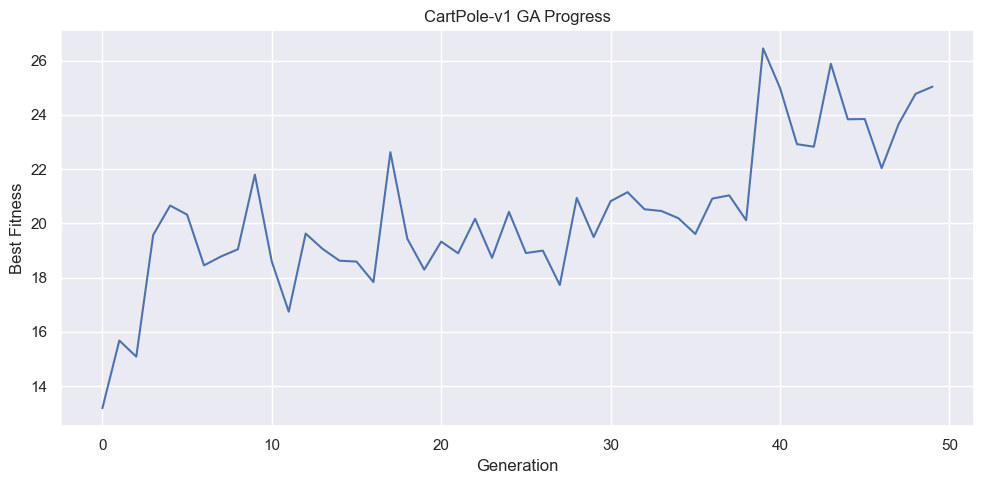

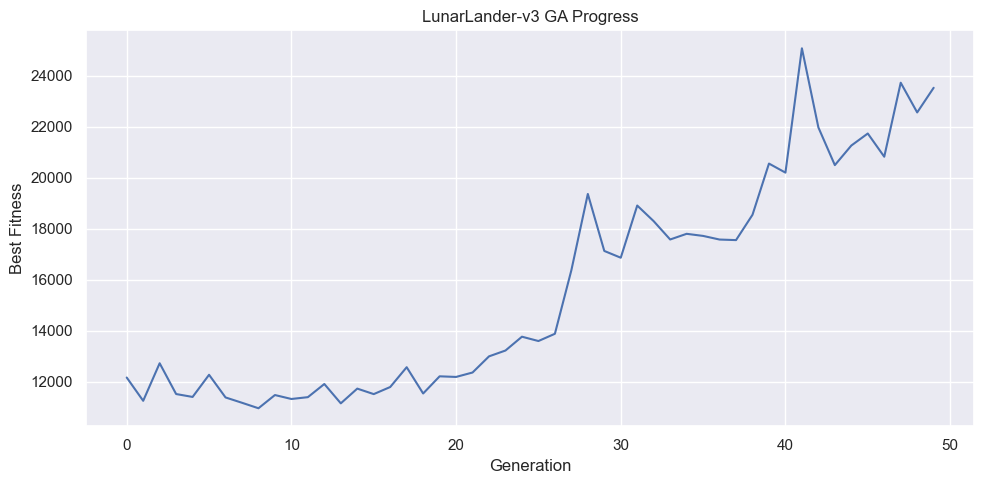

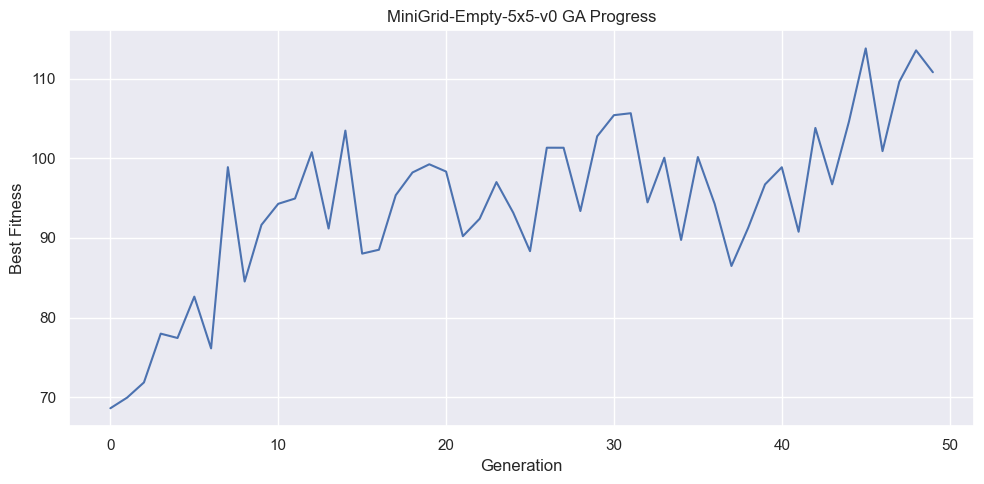

In [48]:
def plot_ga(history, title):
  plt.figure()
  plt.plot(history)
  plt.xlabel('Generation')
  plt.ylabel('Best Fitness')
  plt.title(title)
  plt.tight_layout()
  plt.show()

plot_ga(hist_cp, 'CartPole-v1 GA Progress')
plot_ga(hist_ln, 'LunarLander-v3 GA Progress')
plot_ga(hist_mg, 'MiniGrid-Empty-5x5-v0 GA Progress')